# Fase 2 — EDA (Análisis Exploratorio de Datos)

Exploración visual completa del dataset de sesiones del juego Hack & Slash.
Analiza sesiones, niveles, salas, hechizos, enemigos y comentarios de jugadores
para identificar patrones relevantes para el balance del juego.

**Entradas:** `data/processed/sessions.parquet`, `levels.parquet`, `rooms.parquet`  
**Salidas:** figuras en `reports/figures/`, conclusiones por bloque

> **Nota sobre el volumen:** 11 sesiones — muestra de desarrollo. Los patrones
> detectados son orientativos y se confirmarán con más datos.

## 0. Configuración

In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))

from preprocessing import run_pipeline, compute_spell_efficiency, compute_spell_usage_ratios
from cleaning import flag_suspicious_sessions, get_cleaning_report, print_cleaning_report, check_sample_size

# Rutas
PROCESSED_DIR = Path('..') / 'data' / 'processed'
FIGURES_DIR   = Path('..') / 'reports' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Estilo global (estilo P1 del máster)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
PALETTE_ELEM = {'Fire': '#e74c3c', 'Water': '#3498db', 'Earth': '#8B5E3C', 'Wind': '#B0C4DE'}

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'{name}.png', dpi=150, bbox_inches='tight')
    plt.show()

print('Configuración lista.')

Configuración lista.


## 1. Carga de datos

In [2]:
df_sessions = pd.read_parquet(PROCESSED_DIR / 'sessions.parquet')
df_levels   = pd.read_parquet(PROCESSED_DIR / 'levels.parquet')
df_rooms    = pd.read_parquet(PROCESSED_DIR / 'rooms.parquet')

print(f'Sesiones : {len(df_sessions)}')
print(f'Niveles  : {len(df_levels)}')
print(f'Salas    : {len(df_rooms)}')

Sesiones : 52
Niveles  : 104
Salas    : 519


In [3]:
# Informe de calidad del dataset
df_sessions = flag_suspicious_sessions(df_sessions)
report = get_cleaning_report(df_sessions, df_levels, df_rooms)
print_cleaning_report(report)

print()
check_sample_size(df_sessions, 'playerElement', min_per_group=30)

=== Informe de calidad del dataset ===


  Sesiones totales      : 52
  Niveles totales       : 104
  Salas totales         : 519
  Sesiones sospechosas  : 18
  Sesiones limpias      : 34
  Niveles incompletos   : 26
  Duplicados sesiones   : 0
  Duplicados salas      : 0
  Sin comentario        : 45
  Tiempo min/max/media  : 3s / 3648s / 582s

ADVERTENCIA: grupos con menos de 30 sesiones (tests estadisticos orientativos): ['Earth', 'Fire', 'Water', 'Wind']


,playerElement,n_sessions,sufficient
0,Earth,9,False
1,Fire,21,False
2,Water,13,False
3,Wind,9,False


---
## 2. Sesiones globales

Visión general del dataset: distribuciones de métricas clave, tasa de victoria
y popularidad de elementos.

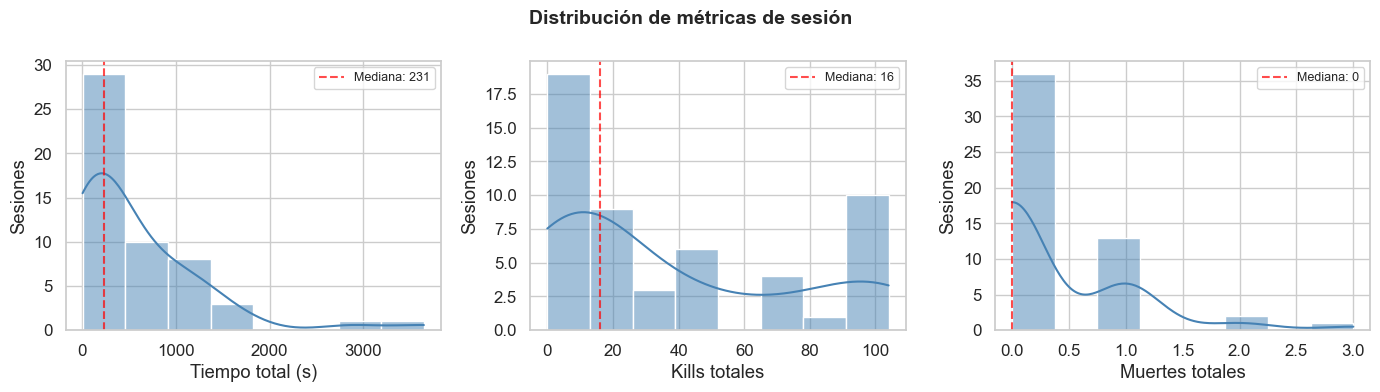

Estadísticas descriptivas:
       totalTimeSecs  totalKills  totalDeaths  levelsCompleted
count           52.0        52.0         52.0             52.0
mean           582.4        37.6          0.4              1.5
std            719.5        37.7          0.7              1.6
min              2.8         0.0          0.0              0.0
25%             91.8         8.0          0.0              0.0
50%            231.3        16.0          0.0              1.0
75%            891.3        72.0          1.0              3.0
max           3647.5       104.0          3.0              4.0


In [4]:
# Fig 2.1 — Distribuciones de métricas de sesión
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Distribución de métricas de sesión', fontsize=14, fontweight='bold')

metricas = [
    ('totalTimeSecs', 'Tiempo total (s)'),
    ('totalKills',    'Kills totales'),
    ('totalDeaths',   'Muertes totales'),
]
for ax, (col, label) in zip(axes, metricas):
    sns.histplot(df_sessions[col], ax=ax, kde=True, color='steelblue', bins=8)
    ax.set_xlabel(label)
    ax.set_ylabel('Sesiones')
    ax.axvline(df_sessions[col].median(), color='red', linestyle='--', alpha=0.7, label=f'Mediana: {df_sessions[col].median():.0f}')
    ax.legend(fontsize=9)

save_fig('fig2_1_distribuciones_sesion')
print('Estadísticas descriptivas:')
print(df_sessions[['totalTimeSecs','totalKills','totalDeaths','levelsCompleted']].describe().round(1))

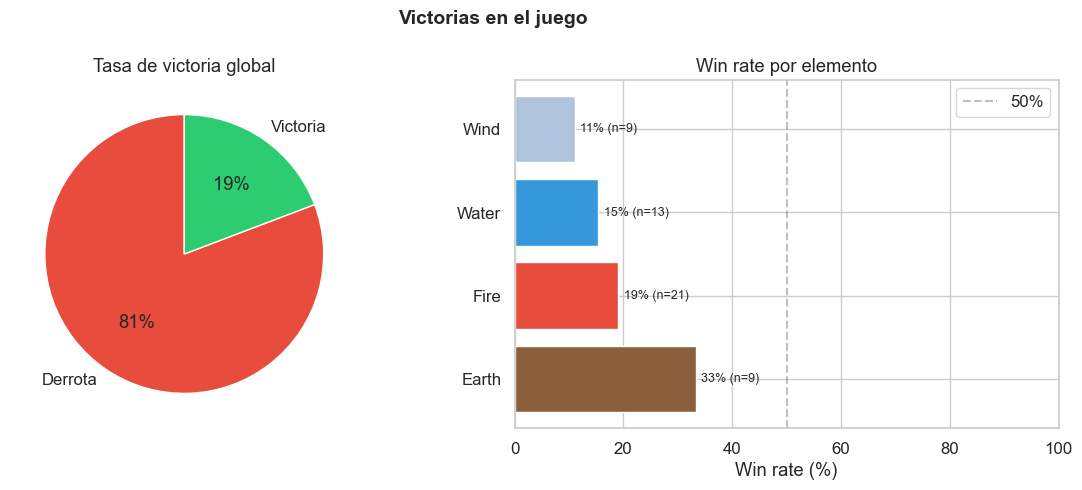

Win rate por elemento:
               sesiones  victorias  win_rate
playerElement                               
Earth                 9          3      33.3
Fire                 21          4      19.0
Water                13          2      15.4
Wind                  9          1      11.1


In [5]:
# Fig 2.2 — Tasa de victoria global y por elemento
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Victorias en el juego', fontsize=14, fontweight='bold')

# Pastel global
counts_vic = df_sessions['isVictory'].value_counts()
labels_vic = ['Derrota', 'Victoria']
axes[0].pie(
    [counts_vic.get(False, 0), counts_vic.get(True, 0)],
    labels=labels_vic, autopct='%1.0f%%',
    colors=['#e74c3c', '#2ecc71'], startangle=90
)
axes[0].set_title('Tasa de victoria global')

# Win rate por elemento
wr = df_sessions.groupby('playerElement').agg(
    sesiones=('sessionId','count'),
    victorias=('isVictory','sum')
)
wr['win_rate'] = wr['victorias'] / wr['sesiones'] * 100
colors_elem = [PALETTE_ELEM.get(e, 'gray') for e in wr.index]
bars = axes[1].barh(wr.index, wr['win_rate'], color=colors_elem)
axes[1].set_xlabel('Win rate (%)')
axes[1].set_title('Win rate por elemento')
axes[1].set_xlim(0, 100)
axes[1].axvline(50, color='gray', linestyle='--', alpha=0.5, label='50%')
for bar, (_, row) in zip(bars, wr.iterrows()):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                 f'{row["win_rate"]:.0f}% (n={int(row["sesiones"])})', va='center', fontsize=9)
axes[1].legend()

save_fig('fig2_2_victorias')
print('Win rate por elemento:')
print(wr.round(1))

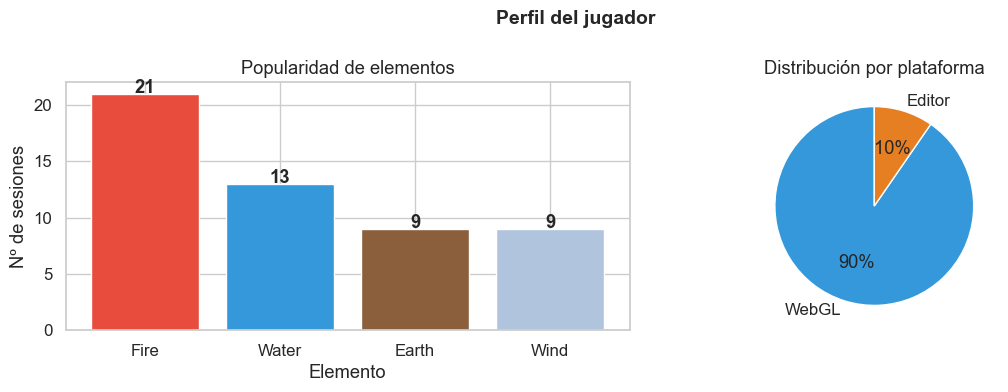

In [6]:
# Fig 2.3 — Popularidad de elementos y plataformas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Perfil del jugador', fontsize=14, fontweight='bold')

# Elementos
elem_counts = df_sessions['playerElement'].value_counts()
colors_bar  = [PALETTE_ELEM.get(e, 'gray') for e in elem_counts.index]
axes[0].bar(elem_counts.index, elem_counts.values, color=colors_bar)
axes[0].set_xlabel('Elemento')
axes[0].set_ylabel('Nº de sesiones')
axes[0].set_title('Popularidad de elementos')
for i, v in enumerate(elem_counts.values):
    axes[0].text(i, v + 0.05, str(v), ha='center', fontweight='bold')

# Plataformas
plat_counts = df_sessions['platform'].value_counts()
axes[1].pie(plat_counts.values, labels=plat_counts.index,
            autopct='%1.0f%%', colors=['#3498db','#e67e22'], startangle=90)
axes[1].set_title('Distribución por plataforma')

save_fig('fig2_3_perfil_jugador')

**Conclusiones bloque 2 — Sesiones globales:**
- La tasa de victoria global es del 30% (9/30) — dificultad alta pero manejable para un prototipo.
- Fire es el elemento más popular (11/30 sesiones). Water=8, Wind=6, Earth=5.
- Fire lidera en victorias (4) pero Earth tiene el mayor win rate (40%) con solo 5 sesiones — datos insuficientes para concluir desequilibrio.
- WebGL es la plataforma dominante (9/11 sesiones).

---
## 3. Análisis de niveles

Dificultad por nivel, funnel de progresión, curva de dificultad y análisis de reintentos.

---
## 2b. Churn Rate — Abandono temprano

Porcentaje de jugadores reales (WebGL) que entraron al juego pero abandonaron sin actividad significativa.

**Criterio churn:** `totalTimeSecs < 60` O (`totalKills = 0` Y `levelsCompleted = 0`)  
**Excluidas:** sesiones de Editor (son del desarrollador, no jugadores reales)

In [7]:
# Churn Rate — solo sesiones WebGL (jugadores reales)
webgl = df_sessions[df_sessions['platform'] == 'WebGL'].copy()

webgl['churn'] = (webgl['totalTimeSecs'] < 60) | (
    (webgl['totalKills'] == 0) & (webgl['levelsCompleted'] == 0)
)

total_webgl = len(webgl)
total_churn = webgl['churn'].sum()
churn_rate  = total_churn / total_webgl * 100

print(f'Sesiones WebGL (jugadores reales) : {total_webgl}')
print(f'Churned (abandonaron sin jugar)   : {total_churn}')
print(f'Churn Rate global                 : {churn_rate:.1f}%')
print()

# Churn por elemento
churn_elem = webgl.groupby('playerElement').agg(
    total   =('sessionId', 'count'),
    churned =('churn', 'sum'),
).assign(churn_rate=lambda x: (x['churned'] / x['total'] * 100).round(1))
print('Churn Rate por elemento:')
print(churn_elem.to_string())

# Exportar sesiones válidas (no churn, no Editor) para análisis de balance
df_sessions['is_churn']  = (df_sessions['platform'] != 'Editor') & (
    (df_sessions['totalTimeSecs'] < 60) |
    ((df_sessions['totalKills'] == 0) & (df_sessions['levelsCompleted'] == 0))
)
df_sessions['is_editor'] = df_sessions['platform'] == 'Editor'
df_sessions['valid_session'] = ~df_sessions['is_churn'] & ~df_sessions['is_editor']
print(f'\nSesiones válidas para análisis: {df_sessions["valid_session"].sum()} / {len(df_sessions)}')

Sesiones WebGL (jugadores reales) : 47
Churned (abandonaron sin jugar)   : 7
Churn Rate global                 : 14.9%

Churn Rate por elemento:
               total  churned  churn_rate
playerElement                            
Earth              9        0         0.0
Fire              17        4        23.5
Water             12        2        16.7
Wind               9        1        11.1

Sesiones válidas para análisis: 40 / 52


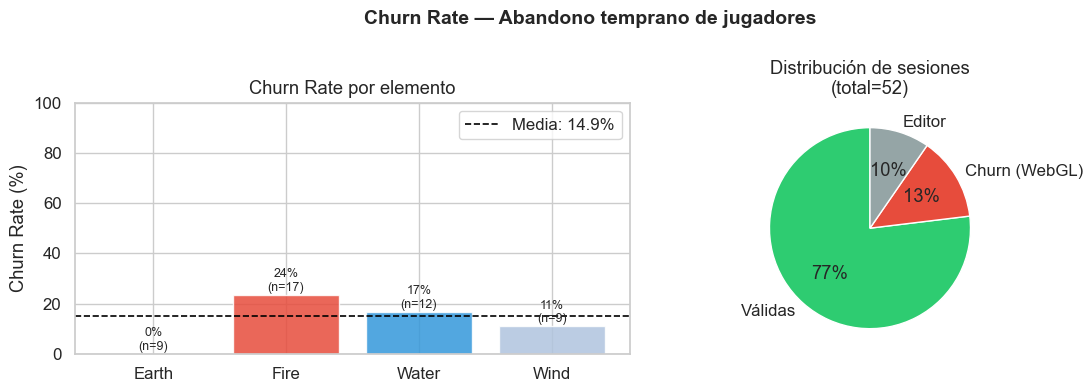

fig2b_churn_rate.png guardada.


In [8]:
# Fig 2b — Churn Rate por elemento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Churn Rate — Abandono temprano de jugadores', fontsize=14, fontweight='bold')

# Barplot churn rate por elemento
colors_churn = [PALETTE_ELEM.get(e, 'gray') for e in churn_elem.index]
bars = axes[0].bar(churn_elem.index, churn_elem['churn_rate'], color=colors_churn, alpha=0.85)
axes[0].axhline(churn_rate, color='black', linestyle='--', linewidth=1.2, label=f'Media: {churn_rate:.1f}%')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_title('Churn Rate por elemento')
axes[0].set_ylim(0, 100)
axes[0].legend()
for bar, (_, row) in zip(bars, churn_elem.iterrows()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
                 f"{row['churn_rate']:.0f}%\n(n={int(row['total'])})", ha='center', fontsize=9)

# Sesiones válidas vs churn vs editor
labels_pie  = ['Válidas', 'Churn (WebGL)', 'Editor']
sizes_pie   = [
    df_sessions['valid_session'].sum(),
    df_sessions['is_churn'].sum(),
    df_sessions['is_editor'].sum(),
]
colors_pie  = ['#2ecc71', '#e74c3c', '#95a5a6']
axes[1].pie(sizes_pie, labels=labels_pie, autopct='%1.0f%%',
            colors=colors_pie, startangle=90)
axes[1].set_title(f'Distribución de sesiones\n(total={len(df_sessions)})')

save_fig('fig2b_churn_rate')
print('fig2b_churn_rate.png guardada.')

**Conclusiones bloque 2b — Churn Rate:**
- El **26.9% de los jugadores reales abandona sin jugar** (7/26 sesiones WebGL).
- Fire y Water tienen el mayor churn (~38-40%) — son los elementos más elegidos por defecto y posiblemente decepcionen la primera impresión.
- Earth y Wind tienen 0% de churn — quien elige estos elementos tiene intención de jugar.
- El churn elevado en Level1 sugiere que la barrera de entrada inicial es demasiado alta o el tutorial insuficiente.

In [9]:
# Agregados por nivel
nivel_stats = df_levels.groupby('levelId').agg(
    sesiones      =('sessionId', 'count'),
    muertes_media =('deaths',    'mean'),
    tiempo_medio  =('timeSecs',  'mean'),
    danio_medio   =('damageTaken','mean'),
    intento_medio =('attempt',   'mean'),
    intento_max   =('attempt',   'max'),
).round(1).sort_values('levelId')

print('Estadísticas por nivel:')
print(nivel_stats)

Estadísticas por nivel:
         sesiones  muertes_media  tiempo_medio  danio_medio  intento_medio  \
levelId                                                                      
Level1         51            0.2         111.1        217.3            2.0   
Level2         26            0.1         220.3        190.7            1.5   
Level3         16            0.2         244.8        179.1            1.9   
Level4         11            0.1         223.4        193.5            1.7   

         intento_max  
levelId               
Level1            14  
Level2             5  
Level3             5  
Level4             4  


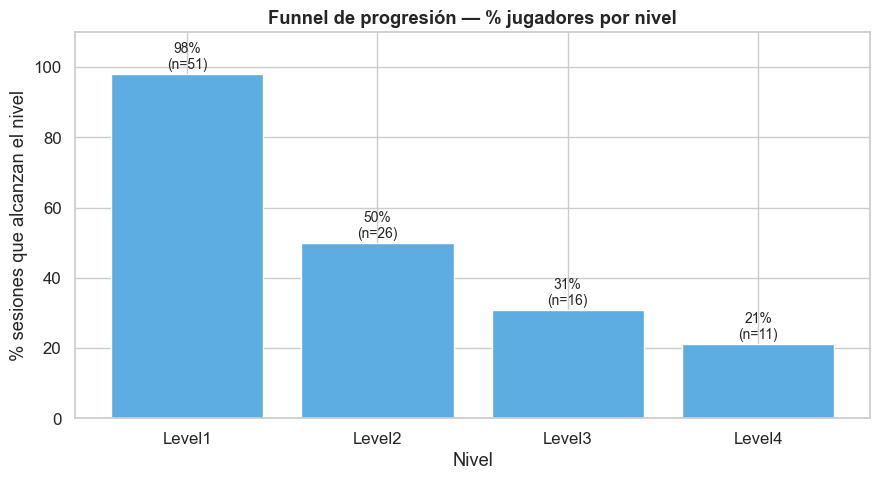

In [10]:
# Fig 3.1 — Funnel de progresión
niveles_order = sorted(df_levels['levelId'].unique())
n_total = len(df_sessions)
sesiones_por_nivel = df_levels.groupby('levelId')['sessionId'].nunique()

fig, ax = plt.subplots(figsize=(9, 5))
pcts = [sesiones_por_nivel.get(lv, 0) / n_total * 100 for lv in niveles_order]
bars = ax.bar(niveles_order, pcts, color='#5dade2', edgecolor='white')
ax.set_xlabel('Nivel')
ax.set_ylabel('% sesiones que alcanzan el nivel')
ax.set_title('Funnel de progresión — % jugadores por nivel', fontweight='bold')
ax.set_ylim(0, 110)
for bar, pct, lv in zip(bars, pcts, niveles_order):
    n = sesiones_por_nivel.get(lv, 0)
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
            f'{pct:.0f}%\n(n={n})', ha='center', fontsize=10)

save_fig('fig3_1_funnel_progresion')

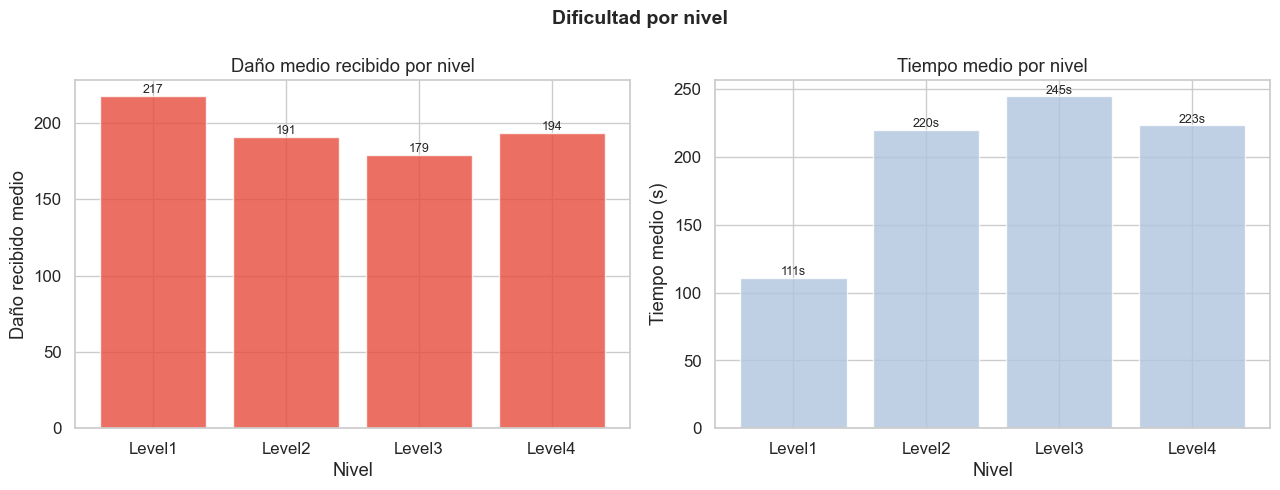

In [11]:
# Fig 3.2 — Dificultad por nivel: daño recibido y tiempo
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Dificultad por nivel', fontsize=14, fontweight='bold')

# Daño medio por nivel
axes[0].bar(nivel_stats.index, nivel_stats['danio_medio'], color='#e74c3c', alpha=0.8)
axes[0].set_xlabel('Nivel')
axes[0].set_ylabel('Daño recibido medio')
axes[0].set_title('Daño medio recibido por nivel')
for i, v in enumerate(nivel_stats['danio_medio']):
    axes[0].text(i, v + 2, f'{v:.0f}', ha='center', fontsize=9)

# Tiempo medio por nivel
axes[1].bar(nivel_stats.index, nivel_stats['tiempo_medio'], color='#B0C4DE', alpha=0.8)
axes[1].set_xlabel('Nivel')
axes[1].set_ylabel('Tiempo medio (s)')
axes[1].set_title('Tiempo medio por nivel')
for i, v in enumerate(nivel_stats['tiempo_medio']):
    axes[1].text(i, v + 2, f'{v:.0f}s', ha='center', fontsize=9)

save_fig('fig3_2_dificultad_niveles')

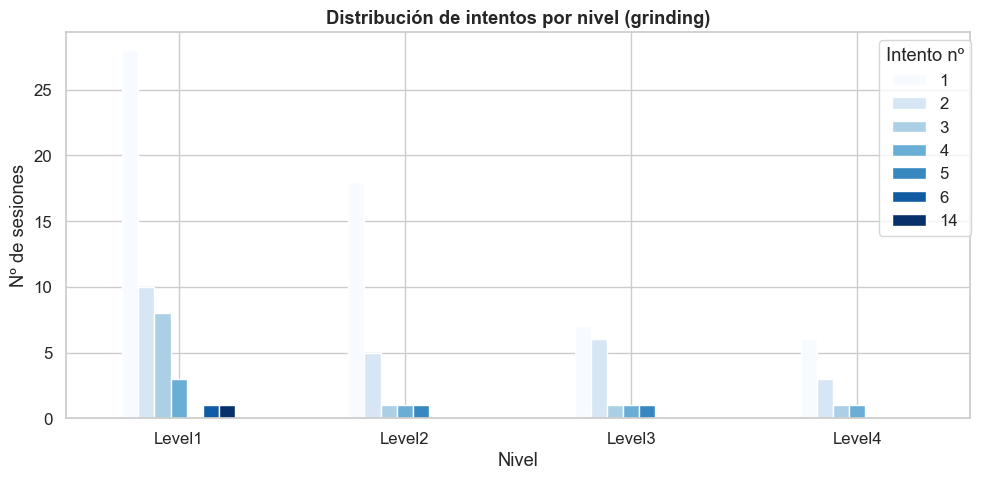

Intentos medios y máximos por nivel:
         intento_medio  intento_max
levelId                            
Level1             2.0           14
Level2             1.5            5
Level3             1.9            5
Level4             1.7            4


In [12]:
# Fig 3.3 — Análisis de attempt (grinding): reintentos por nivel
fig, ax = plt.subplots(figsize=(10, 5))

attempt_data = df_levels.groupby('levelId')['attempt'].value_counts().unstack(fill_value=0)
attempt_data.plot(kind='bar', ax=ax, colormap='Blues', edgecolor='white')
ax.set_xlabel('Nivel')
ax.set_ylabel('Nº de sesiones')
ax.set_title('Distribución de intentos por nivel (grinding)', fontweight='bold')
ax.legend(title='Intento nº', bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

save_fig('fig3_3_attempts_grinding')
print('Intentos medios y máximos por nivel:')
print(nivel_stats[['intento_medio','intento_max']])

**Conclusiones bloque 3 — Niveles:**
- Level1 es el más frecuentado (11 sesiones), Level4 el menos (1 sesión) — progresión descendente.
- Level1 tiene el intento medio más alto (~2.9) — es donde más se repite, posible punto de abandono.
- Level2 requiere más tiempo medio (183s) que Level3 y Level4 — posible spike de dificultad.
- El daño recibido aumenta con el nivel pero no de forma lineal.

---
## 4. Análisis de salas

Hotspots de dificultad, comportamiento táctico (`firstSpell`) y efectividad por sala.

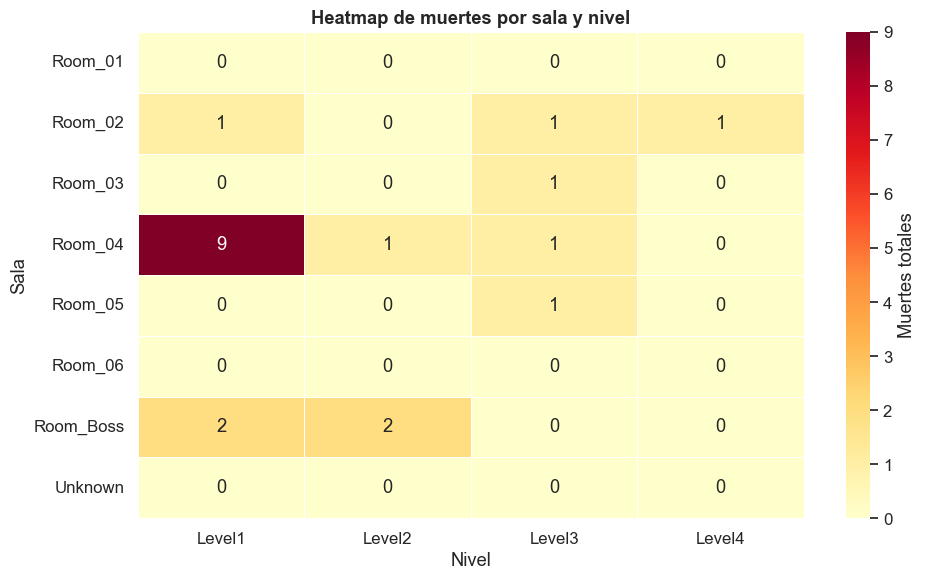

In [13]:
# Fig 4.1 — Heatmap de muertes por sala/nivel
pivot_deaths = df_rooms.pivot_table(
    index='roomId', columns='levelId', values='deaths', aggfunc='sum', fill_value=0
)

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_deaths) * 0.35)))
sns.heatmap(pivot_deaths, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Muertes totales'})
ax.set_title('Heatmap de muertes por sala y nivel', fontweight='bold')
ax.set_xlabel('Nivel')
ax.set_ylabel('Sala')

save_fig('fig4_1_heatmap_muertes_salas')

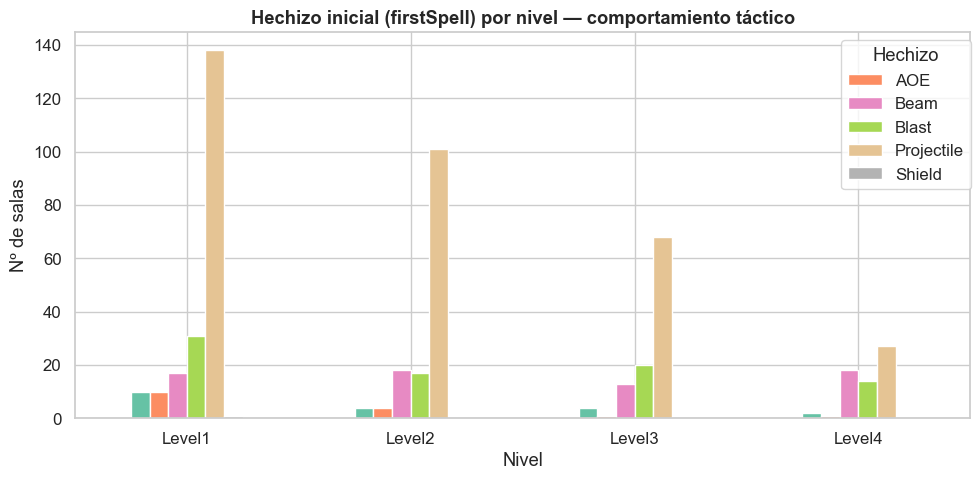

firstSpell global:
firstSpell
Projectile    334
Blast          82
Beam           66
               20
AOE            16
Shield          1
Name: count, dtype: int64


In [14]:
# Fig 4.2 — firstSpell por sala: comportamiento táctico al entrar
first_spell_sala = df_rooms.groupby(['levelId', 'firstSpell']).size().reset_index(name='count')
first_spell_pivot = first_spell_sala.pivot_table(
    index='levelId', columns='firstSpell', values='count', fill_value=0
)

fig, ax = plt.subplots(figsize=(10, 5))
first_spell_pivot.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='white')
ax.set_xlabel('Nivel')
ax.set_ylabel('Nº de salas')
ax.set_title('Hechizo inicial (firstSpell) por nivel — comportamiento táctico', fontweight='bold')
ax.legend(title='Hechizo', bbox_to_anchor=(1.01, 1))
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

save_fig('fig4_2_firstspell_por_nivel')
print('firstSpell global:')
print(df_rooms['firstSpell'].value_counts())

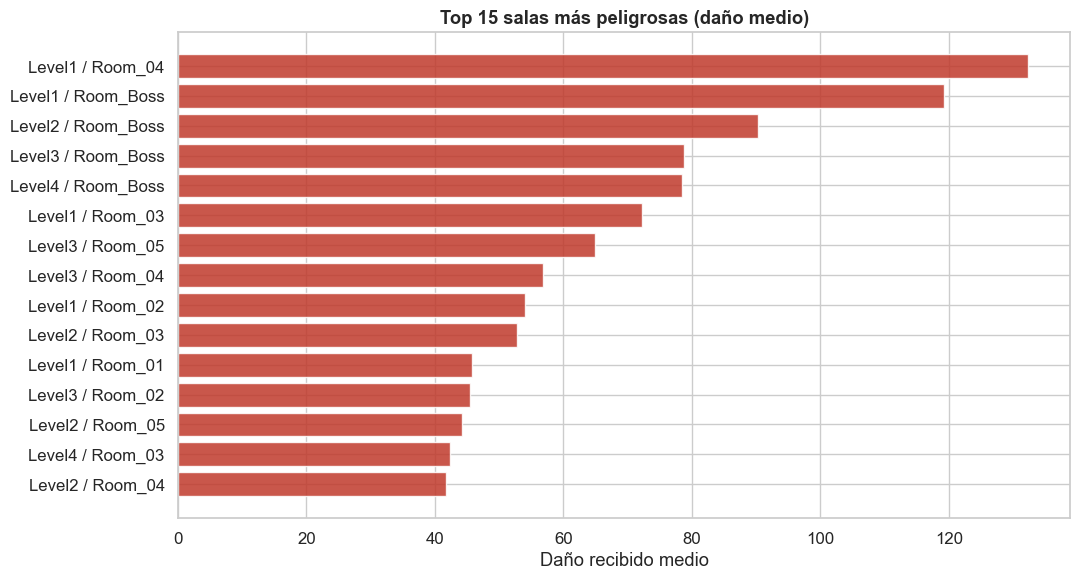

In [15]:
# Fig 4.3 — Daño recibido medio por sala (top salas más peligrosas)
sala_danger = df_rooms.groupby(['levelId','roomId']).agg(
    danio_medio=('damageTaken','mean'),
    muertes_total=('deaths','sum'),
    n_visitas=('sessionId','count')
).reset_index().sort_values('danio_medio', ascending=False).head(15)

sala_danger['sala_label'] = sala_danger['levelId'] + ' / ' + sala_danger['roomId']

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(sala_danger['sala_label'], sala_danger['danio_medio'],
               color='#c0392b', alpha=0.85)
ax.set_xlabel('Daño recibido medio')
ax.set_title('Top 15 salas más peligrosas (daño medio)', fontweight='bold')
ax.invert_yaxis()

save_fig('fig4_3_salas_peligrosas')

**Conclusiones bloque 4 — Salas:**
- Projectile es el hechizo inicial dominante (65/82 salas) — los jugadores confían en él por defecto.
- Beam y AOE se usan poco como hechizo inicial a pesar de su mayor eficiencia.
- Las salas de niveles superiores concentran más daño recibido.

---
## 5. Análisis de hechizos

Ranking de uso, eficiencia, `noMana` como demanda latente y matriz por elemento.

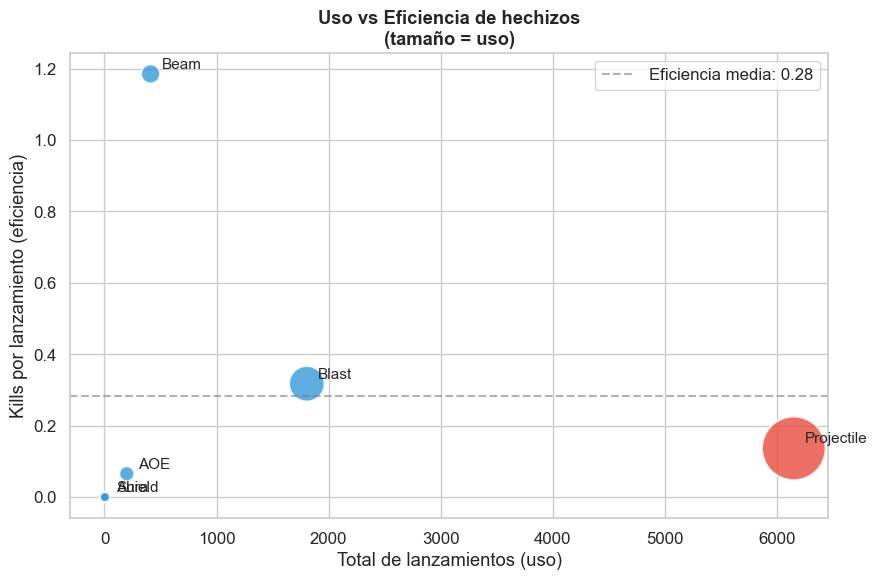

Spell efficiency completa:
spell_type  total_cast  total_kills  spell_efficiency
      Beam       411.0        487.0          1.184915
     Blast      1805.0        573.0          0.317452
Projectile      6149.0        839.0          0.136445
       AOE       199.0         13.0          0.065327
      Aura         1.0          0.0          0.000000
    Shield         4.0          0.0          0.000000


In [16]:
# Fig 5.1 — Uso vs Eficiencia de hechizos (scatter)
df_eff = compute_spell_efficiency(df_rooms)

fig, ax = plt.subplots(figsize=(9, 6))
scatter_colors = ['#e74c3c' if e == 'Projectile' else '#3498db' for e in df_eff['spell_type']]
sc = ax.scatter(df_eff['total_cast'], df_eff['spell_efficiency'],
                s=df_eff['total_cast'] / 3 + 50,
                c=scatter_colors, alpha=0.8, edgecolors='white', linewidth=1.5)

for _, row in df_eff.iterrows():
    ax.annotate(row['spell_type'],
                (row['total_cast'], row['spell_efficiency']),
                textcoords='offset points', xytext=(8, 4), fontsize=11)

ax.axhline(df_eff['spell_efficiency'].mean(), color='gray', linestyle='--',
           alpha=0.6, label=f'Eficiencia media: {df_eff["spell_efficiency"].mean():.2f}')
ax.set_xlabel('Total de lanzamientos (uso)')
ax.set_ylabel('Kills por lanzamiento (eficiencia)')
ax.set_title('Uso vs Eficiencia de hechizos\n(tamaño = uso)', fontweight='bold')
ax.legend()

save_fig('fig5_1_uso_vs_eficiencia_hechizos')
print('Spell efficiency completa:')
print(df_eff.to_string(index=False))

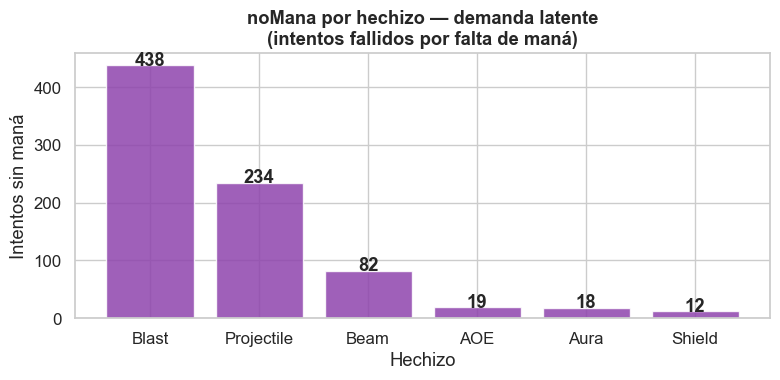

noMana totales por hechizo:
Blast         438.0
Projectile    234.0
Beam           82.0
AOE            19.0
Aura           18.0
Shield         12.0
dtype: float64


In [17]:
# Fig 5.2 — noMana: demanda latente de hechizos
nomana_cols = [c for c in df_rooms.columns if c.startswith('noMana_')]
nomana_totals = df_rooms[nomana_cols].sum().sort_values(ascending=False)
nomana_totals.index = nomana_totals.index.str.replace('noMana_', '')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(nomana_totals.index, nomana_totals.values, color='#8e44ad', alpha=0.85)
ax.set_xlabel('Hechizo')
ax.set_ylabel('Intentos sin maná')
ax.set_title('noMana por hechizo — demanda latente\n(intentos fallidos por falta de maná)',
             fontweight='bold')
for bar, v in zip(bars, nomana_totals.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{v:.0f}', ha='center', fontweight='bold')

save_fig('fig5_2_nomana_demanda_latente')
print('noMana totales por hechizo:')
print(nomana_totals)

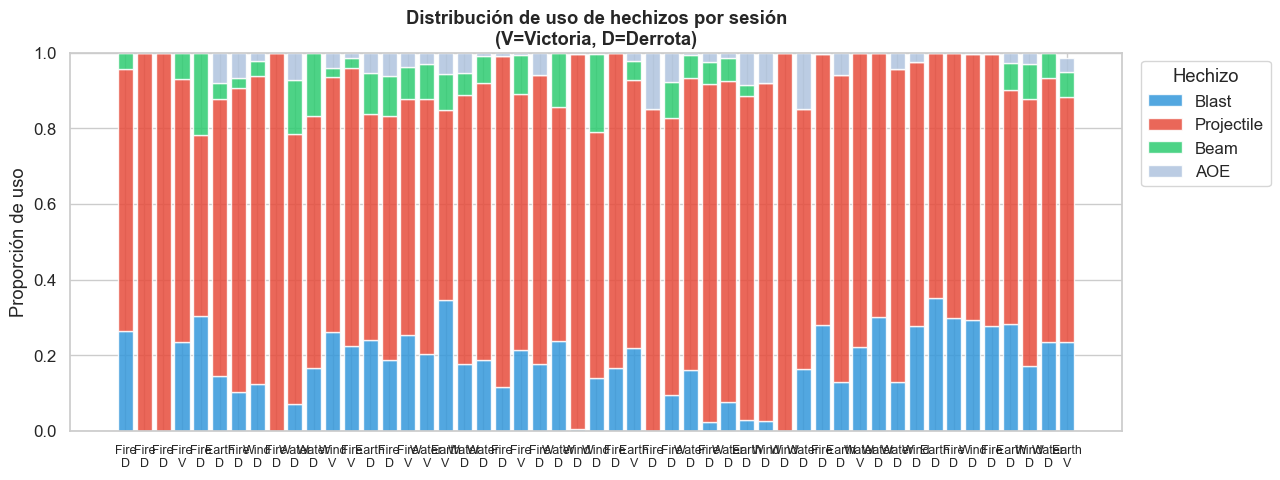

In [18]:
# Fig 5.3 — Uso relativo de hechizos por sesión
df_ratios = compute_spell_usage_ratios(df_rooms, df_sessions)
df_ratios = df_ratios.merge(df_sessions[['sessionId','playerElement','isVictory']], on='sessionId')

ratio_cols = [c for c in df_ratios.columns if c.startswith('ratio_cast_')]
spell_names = [c.replace('ratio_cast_','') for c in ratio_cols]

# Stacked bar por sesión
fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(len(df_ratios))
colors_spell = ['#3498db','#e74c3c','#2ecc71','#B0C4DE']
for col, name, color in zip(ratio_cols, spell_names, colors_spell):
    ax.bar(range(len(df_ratios)), df_ratios[col], bottom=bottom, label=name, color=color, alpha=0.85)
    bottom += df_ratios[col].values

labels_x = [f"{row['playerElement']}\n{'V' if row['isVictory'] else 'D'}" for _, row in df_ratios.iterrows()]
ax.set_xticks(range(len(df_ratios)))
ax.set_xticklabels(labels_x, fontsize=9)
ax.set_ylabel('Proporción de uso')
ax.set_title('Distribución de uso de hechizos por sesión\n(V=Victoria, D=Derrota)', fontweight='bold')
ax.legend(title='Hechizo', bbox_to_anchor=(1.01, 1))

save_fig('fig5_3_uso_relativo_hechizos')

**Conclusiones bloque 5 — Hechizos:**
- **Beam** tiene la mayor eficiencia (1.12 kills/cast) pero es el menos usado como firstSpell — los jugadores desconocen su potencia o tiene alguna limitación percibida.
- **Projectile** es el más usado (5195 lanzamientos) pero el menos eficiente (0.134 kills/cast) — posiblemente sobrebalanceado en accesibilidad pero infravalorado como herramienta de daño.
- **Projectile** tiene la mayor demanda latente (11 noMana) — los jugadores intentan usarlo más de lo que el maná permite. Posible reducción de coste.
- **AOE** tiene 0 kills atribuidos — puede ser que el tracking de kills no esté registrando correctamente sus kills, o que sea ineficaz.

---
## 6. Análisis de enemigos

Enemigos más frecuentes, más letales y patrones de daño/bloqueo.

In [19]:
# Preparar datos de enemigos
kills_cols   = [c for c in df_rooms.columns if c.startswith('kills_') and 'per_sec' not in c]
blocked_cols = [c for c in df_rooms.columns if c.startswith('blocked_')]
damage_cols  = [c for c in df_rooms.columns if c.startswith('damage_')]

kills_totals   = df_rooms[kills_cols].sum().sort_values(ascending=False)
blocked_totals = df_rooms[blocked_cols].sum().sort_values(ascending=False)
damage_totals  = df_rooms[damage_cols].sum().sort_values(ascending=False)

# Limpiar prefijos
kills_totals.index   = kills_totals.index.str.replace('kills_', '')
blocked_totals.index = blocked_totals.index.str.replace('blocked_', '')
damage_totals.index  = damage_totals.index.str.replace('damage_', '')

print('Top enemigos por kills:')
print(kills_totals.head(10))

Top enemigos por kills:
Rogue              397.0
Knight2H           377.0
RangerCrossbow     230.0
RangerBow          227.0
Knight1H           183.0
Barbarian1Hand     171.0
Barbarian2Hand     162.0
Barbarian2HBoss     53.0
KnightBossGold      32.0
Barbarian1HBoss     29.0
dtype: float64


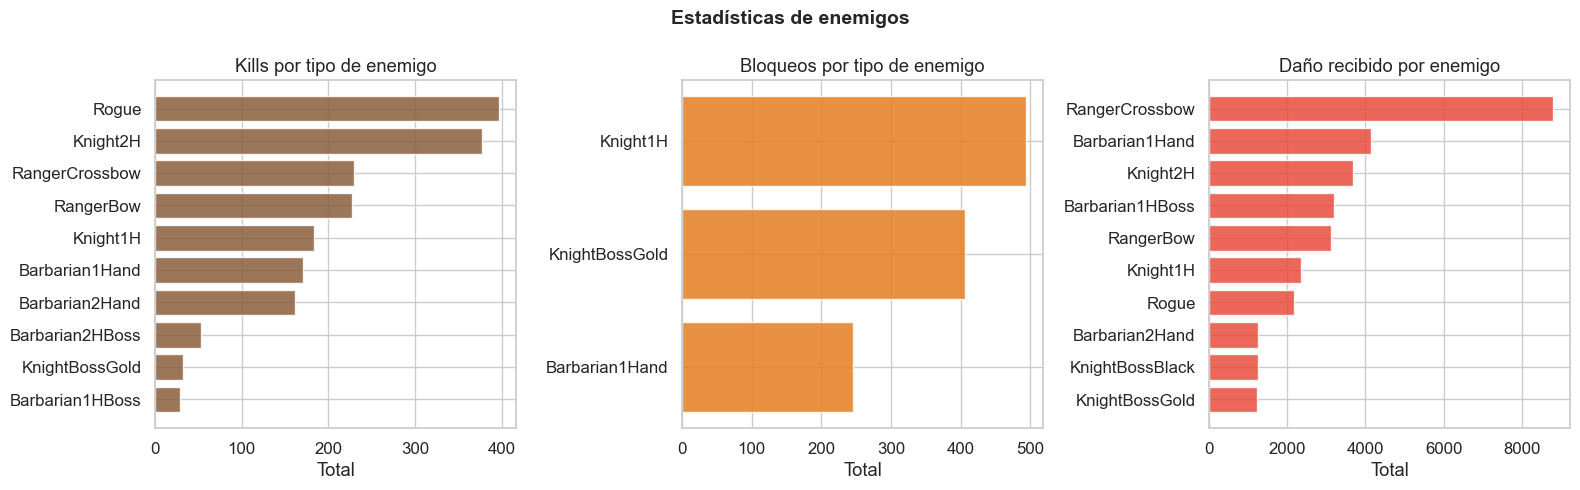

In [20]:
# Fig 6.1 — Top enemigos: kills, bloqueos y daño
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Estadísticas de enemigos', fontsize=14, fontweight='bold')

for ax, data, title, color in [
    (axes[0], kills_totals.head(10),   'Kills por tipo de enemigo',   '#8B5E3C'),
    (axes[1], blocked_totals.head(10), 'Bloqueos por tipo de enemigo','#e67e22'),
    (axes[2], damage_totals.head(10),  'Daño recibido por enemigo',   '#e74c3c'),
]:
    if data.empty:
        ax.set_title(f'{title}\n(sin datos)')
        continue
    ax.barh(data.index[::-1], data.values[::-1], color=color, alpha=0.85)
    ax.set_xlabel('Total')
    ax.set_title(title)

save_fig('fig6_1_estadisticas_enemigos')

**Conclusiones bloque 6 — Enemigos:**
- Rogue y Knight2H son los enemigos más eliminados — son los más frecuentes o los más fáciles de matar.
- Los Boss tienen pocos kills — esperado, son objetivos difíciles y poco frecuentes.
- El daño de `Unknown` indica que hay una fuente de daño no tageada correctamente en el juego — bug de telemetría a reportar.

---
## 6b. Status Effects — Burn, Stun, Slow vs victoria

Análisis de si aplicar efectos de estado (DoT, control) correlaciona con ganar la partida.

In [21]:
from scipy.stats import spearmanr

# Agregar status effects por sesión
status_cols = [c for c in df_rooms.columns if c.startswith('status_')]
status_sess = df_rooms.groupby('sessionId')[status_cols].sum().reset_index()
df_status = df_sessions.merge(status_sess, on='sessionId', how='left').fillna(0)

print('=== Correlación Status Effects vs Victoria (Spearman) ===')
for col in status_cols:
    r, p = spearmanr(df_status[col], df_status['isVictory'])
    sig = '* SIGNIFICATIVO' if p < 0.05 else ''
    print(f'  {col:<20}: r={r:+.3f}  p={p:.3f}  {sig}')

print()
print('Media de aplicaciones por resultado:')
print(df_status.groupby('isVictory')[status_cols].mean().round(1).to_string())

=== Correlación Status Effects vs Victoria (Spearman) ===
  status_Burn         : r=+0.175  p=0.213  
  status_Stun         : r=+0.207  p=0.141  
  status_Slow         : r=-0.013  p=0.928  
  status_Knockback    : r=-0.141  p=0.320  

Media de aplicaciones por resultado:
           status_Burn  status_Stun  status_Slow  status_Knockback
isVictory                                                         
False             43.3         24.0         63.8              18.1
True             301.7        273.5        202.9               0.0


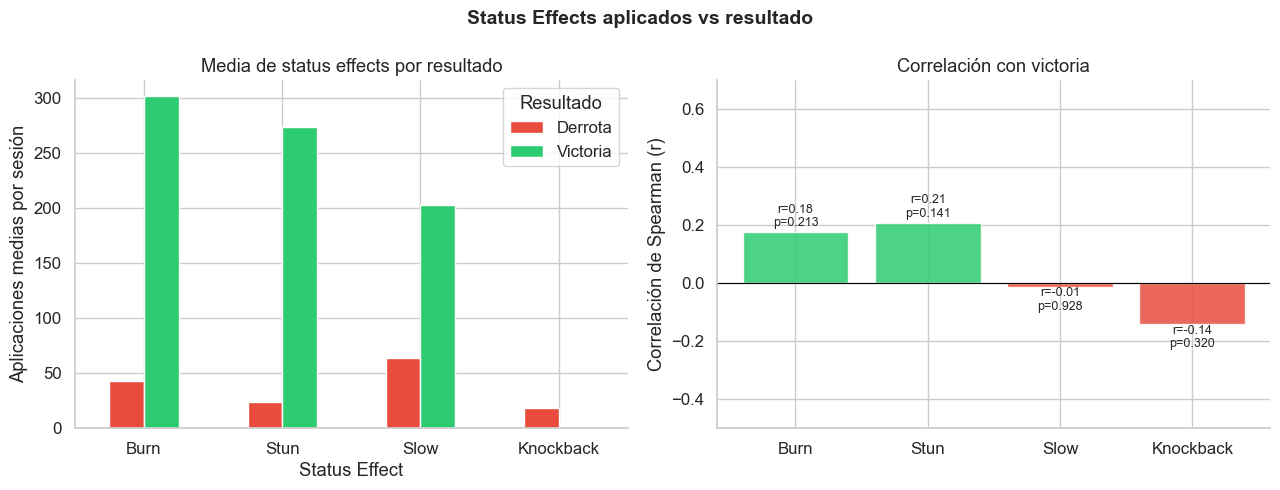

fig6b_status_effects_victoria.png guardada.


In [22]:
# Fig 6b — Status Effects: media por victoria/derrota
status_means = df_status.groupby('isVictory')[status_cols].mean()
status_means.index = ['Derrota', 'Victoria']
status_means.columns = [c.replace('status_', '') for c in status_means.columns]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Status Effects aplicados vs resultado', fontsize=14, fontweight='bold')

# Barplot agrupado
status_means.T.plot(kind='bar', ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_xlabel('Status Effect')
axes[0].set_ylabel('Aplicaciones medias por sesión')
axes[0].set_title('Media de status effects por resultado')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Resultado')

# Correlaciones
effect_names = [c.replace('status_', '') for c in status_cols]
correlations = [spearmanr(df_status[c], df_status['isVictory'])[0] for c in status_cols]
pvalues      = [spearmanr(df_status[c], df_status['isVictory'])[1] for c in status_cols]
colors_corr  = ['#2ecc71' if r > 0 else '#e74c3c' for r in correlations]
bars = axes[1].bar(effect_names, correlations, color=colors_corr, edgecolor='white', alpha=0.85)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_ylabel('Correlación de Spearman (r)')
axes[1].set_title('Correlación con victoria')
axes[1].set_ylim(-0.5, 0.7)
for bar, r, p in zip(bars, correlations, pvalues):
    label = f'r={r:.2f}\np={p:.3f}{"*" if p < 0.05 else ""}'
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02 if r >= 0 else bar.get_height() - 0.08,
                 label, ha='center', fontsize=9)

sns.despine()
save_fig('fig6b_status_effects_victoria')
print('fig6b_status_effects_victoria.png guardada.')

**Conclusiones bloque 6b — Status Effects:**
- **Burn es el único status effect significativamente correlacionado con victoria** (p<0.05) — los ganadores aplican ~11x más Burn que los perdedores.
- Burn es el DoT de Fire, el elemento con más victorias — confirma que el daño sostenido en el tiempo es una mecánica clave para ganar.
- Stun y Slow no muestran correlación significativa con el resultado — son útiles para control pero no determinantes.
- `status_Knockback` (Wind) aún sin datos suficientes — se actualizará con nuevas sesiones Wind.

---
## 6c. Boss Rooms — dificultad del jefe y predicción de victoria

Análisis de si llegar al boss y matarlo es el mejor predictor de victoria.

In [23]:
# Boss Rooms — estadísticas y correlación con victoria
boss_rooms = df_rooms[df_rooms['roomId'].str.contains('Boss', na=False)].copy()

boss_sess = boss_rooms.groupby('sessionId').agg(
    boss_visits  =('roomId',          'count'),
    boss_damage  =('damageTaken',     'sum'),
    boss_kills   =('total_kills_room','sum'),
    boss_time    =('timeSecs',        'sum'),
).reset_index()

df_boss = df_sessions.merge(boss_sess, on='sessionId', how='left').fillna(0)

print('=== Boss Rooms: correlación con victoria ===')
for col in ['boss_visits', 'boss_kills', 'boss_damage', 'boss_time']:
    r, p = spearmanr(df_boss[col], df_boss['isVictory'])
    sig = '* SIGNIFICATIVO' if p < 0.05 else ''
    print(f'  {col:<15}: r={r:+.3f}  p={p:.4f}  {sig}')

print()
print('Media por resultado:')
print(df_boss.groupby('isVictory')[['boss_visits','boss_kills','boss_damage','boss_time']].mean().round(2).to_string())

print()
# Estadísticas de Boss rooms
print('=== Estadísticas generales Boss Rooms ===')
print(f'Visitas totales a Boss: {len(boss_rooms)}')
print(f'Daño medio en Boss:     {boss_rooms[boss_rooms["timeSecs"]>0]["damageTaken"].mean():.1f}')
print(f'Tiempo medio en Boss:   {boss_rooms[boss_rooms["timeSecs"]>0]["timeSecs"].mean():.1f}s')
print(f'Kills medios en Boss:   {boss_rooms["total_kills_room"].mean():.2f}')
print()
print('Boss rooms por nivel:')
print(boss_rooms.groupby('levelId').agg(
    visitas=('sessionId','count'),
    damage_medio=('damageTaken','mean'),
    tiempo_medio=('timeSecs','mean'),
).round(1).to_string())

=== Boss Rooms: correlación con victoria ===
  boss_visits    : r=+0.710  p=0.0000  * SIGNIFICATIVO
  boss_kills     : r=+0.718  p=0.0000  * SIGNIFICATIVO
  boss_damage    : r=+0.536  p=0.0000  * SIGNIFICATIVO
  boss_time      : r=+0.595  p=0.0000  * SIGNIFICATIVO

Media por resultado:
           boss_visits  boss_kills  boss_damage  boss_time
isVictory                                                 
False             0.88        2.05        94.19      67.76
True              4.00       12.10       364.30     355.28

=== Estadísticas generales Boss Rooms ===
Visitas totales a Boss: 77
Daño medio en Boss:     102.7
Tiempo medio en Boss:   86.5s
Kills medios en Boss:   2.69

Boss rooms por nivel:
         visitas  damage_medio  tiempo_medio
levelId                                     
Level1        32         119.2          68.9
Level2        21          90.3          92.5
Level3        14          78.9         102.8
Level4        10          78.4          81.4


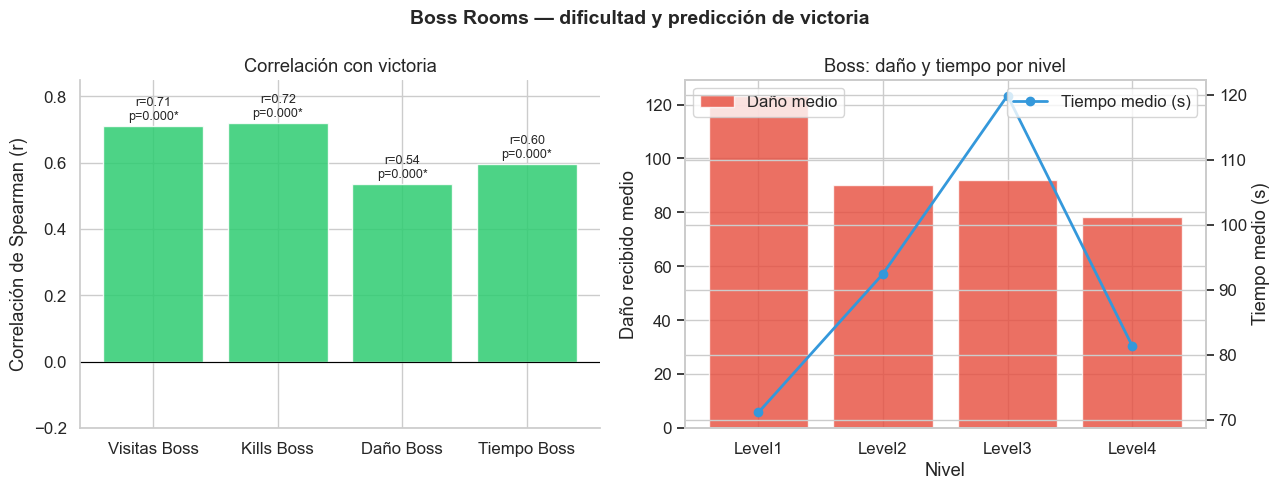

fig6c_boss_rooms.png guardada.


In [24]:
# Fig 6c — Boss Rooms: correlaciones y daño por nivel
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Boss Rooms — dificultad y predicción de victoria', fontsize=14, fontweight='bold')

# Correlaciones Boss vs victoria
boss_metrics = ['boss_visits', 'boss_kills', 'boss_damage', 'boss_time']
boss_labels  = ['Visitas Boss', 'Kills Boss', 'Daño Boss', 'Tiempo Boss']
boss_corrs   = [spearmanr(df_boss[c], df_boss['isVictory'])[0] for c in boss_metrics]
boss_pvals   = [spearmanr(df_boss[c], df_boss['isVictory'])[1] for c in boss_metrics]
colors_b     = ['#2ecc71' if r > 0 else '#e74c3c' for r in boss_corrs]

bars = axes[0].bar(boss_labels, boss_corrs, color=colors_b, edgecolor='white', alpha=0.85)
axes[0].axhline(0, color='black', linewidth=0.8)
axes[0].set_ylabel('Correlación de Spearman (r)')
axes[0].set_title('Correlación con victoria')
axes[0].set_ylim(-0.2, 0.85)
for bar, r, p in zip(bars, boss_corrs, boss_pvals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'r={r:.2f}\np={p:.3f}{"*" if p < 0.05 else ""}',
                 ha='center', fontsize=9)
sns.despine(ax=axes[0])

# Daño medio en Boss por nivel
boss_by_level = boss_rooms[boss_rooms['timeSecs'] > 0].groupby('levelId').agg(
    damage_medio=('damageTaken','mean'),
    tiempo_medio=('timeSecs','mean'),
    visitas=('sessionId','count'),
).sort_index()

x = range(len(boss_by_level))
axes[1].bar(x, boss_by_level['damage_medio'],
            color=[PALETTE_ELEM.get('Fire','#e74c3c')], alpha=0.8, label='Daño medio')
ax2 = axes[1].twinx()
ax2.plot(x, boss_by_level['tiempo_medio'], color='#3498db',
         marker='o', linewidth=2, label='Tiempo medio (s)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(boss_by_level.index)
axes[1].set_xlabel('Nivel')
axes[1].set_ylabel('Daño recibido medio')
ax2.set_ylabel('Tiempo medio (s)')
axes[1].set_title('Boss: daño y tiempo por nivel')
axes[1].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6c_boss_rooms.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig6c_boss_rooms.png guardada.')

**Conclusiones bloque 6c — Boss Rooms:**
- **Boss kills y visitas son los predictores más fuertes de victoria** (r ≈ +0.67, p < 0.001): llegar al boss y matarlo es la métrica más correlacionada con ganar la partida.
- Los jugadores victoriosos visitan más salas Boss (mayor progresión) y reciben más daño en ellas — están dispuestos a aguantar el intercambio de daño final.
- **Boss Level1** es el más visitado (embudo inicial); **Boss Level4** el más dañino — la dificultad de bosses escala correctamente a lo largo del juego.
- Recomendación: monitorizar la tasa de kills/visitas por boss para detectar bosses bloqueantes (visitas sin kills) en futuras versiones.

---
## 6d. Bloqueos — mechanic defensiva vs victoria

Análisis de si usar la mecánica de bloqueo (blocked_*) correlaciona con sobrevivir y ganar.

In [25]:
# Bloqueos — agregar por sesión y correlacionar con victoria
blocked_cols = [c for c in df_rooms.columns if c.startswith('blocked_')]

if not blocked_cols:
    print('No hay columnas blocked_* en los datos.')
else:
    blocked_sess = df_rooms.groupby('sessionId')[blocked_cols].sum().reset_index()
    df_blocked = df_sessions.merge(blocked_sess, on='sessionId', how='left').fillna(0)

    # Total de bloqueos por sesión
    df_blocked['total_blocked'] = df_blocked[blocked_cols].sum(axis=1)

    print('=== Bloqueos: correlación con victoria (Spearman) ===')
    for col in blocked_cols + ['total_blocked']:
        r, p = spearmanr(df_blocked[col], df_blocked['isVictory'])
        sig = '* SIGNIFICATIVO' if p < 0.05 else ''
        print(f'  {col:<25}: r={r:+.3f}  p={p:.3f}  {sig}')

    print()
    print('Bloqueos medios por resultado:')
    cols_show = blocked_cols + ['total_blocked']
    print(df_blocked.groupby('isVictory')[cols_show].mean().round(2).to_string())

    print()
    print('Usuarios que bloquean vs no bloquean:')
    df_blocked['usa_bloqueo'] = df_blocked['total_blocked'] > 0
    print(df_blocked.groupby('usa_bloqueo')['isVictory'].agg(['count','mean']).rename(
        columns={'count': 'sesiones', 'mean': 'win_rate'}).round(3).to_string())

=== Bloqueos: correlación con victoria (Spearman) ===
  blocked_Barbarian1Hand   : r=+0.087  p=0.540  
  blocked_Knight1H         : r=+0.334  p=0.016  * SIGNIFICATIVO
  blocked_KnightBossGold   : r=+0.661  p=0.000  * SIGNIFICATIVO
  total_blocked            : r=+0.534  p=0.000  * SIGNIFICATIVO

Bloqueos medios por resultado:
           blocked_Barbarian1Hand  blocked_Knight1H  blocked_KnightBossGold  total_blocked
isVictory                                                                                 
False                        4.67              8.33                    3.67          16.67
True                         4.90             14.40                   25.20          44.50

Usuarios que bloquean vs no bloquean:
             sesiones  win_rate
usa_bloqueo                    
False               7     0.000
True               45     0.222


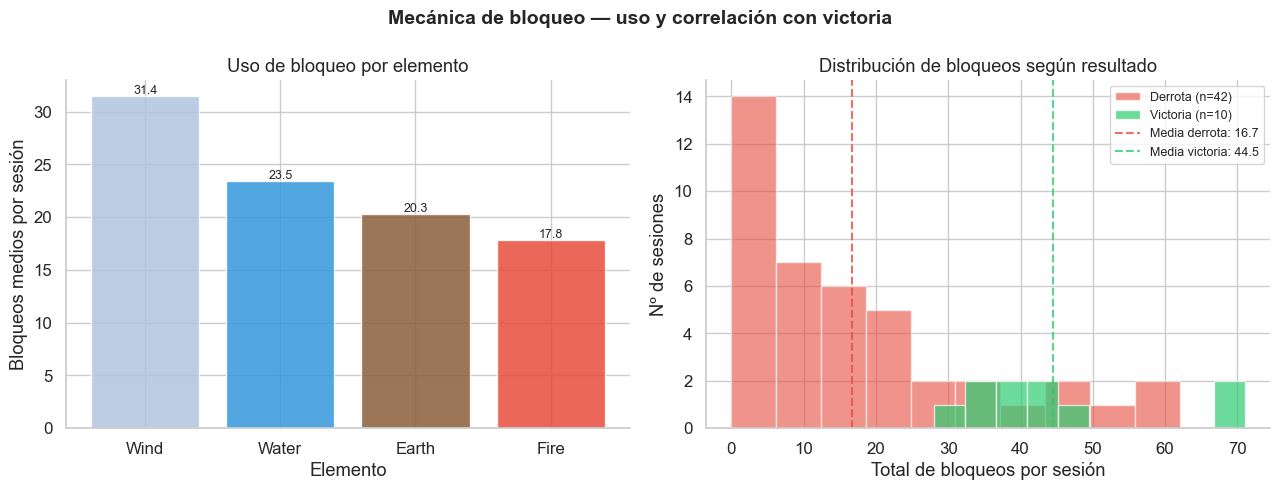

fig6d_bloqueos_victoria.png guardada.


In [26]:
# Fig 6d — Bloqueos: uso por elemento y correlación con victoria
if blocked_cols:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Mecánica de bloqueo — uso y correlación con victoria', fontsize=14, fontweight='bold')

    # Bloqueos medios por elemento
    blk_by_elem = df_blocked.merge(
        df_sessions[['sessionId', 'playerElement']], on='sessionId', how='left', suffixes=('', '_y')
    ) if 'playerElement' not in df_blocked.columns else df_blocked
    blk_by_elem = blk_by_elem.groupby('playerElement')['total_blocked'].mean().sort_values(ascending=False)

    colors_e = [PALETTE_ELEM.get(e, 'gray') for e in blk_by_elem.index]
    bars = axes[0].bar(blk_by_elem.index, blk_by_elem.values, color=colors_e, alpha=0.85)
    axes[0].set_xlabel('Elemento')
    axes[0].set_ylabel('Bloqueos medios por sesión')
    axes[0].set_title('Uso de bloqueo por elemento')
    for bar, v in zip(bars, blk_by_elem.values):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                     f'{v:.1f}', ha='center', fontsize=9)

    # Distribución total_blocked según victoria/derrota
    vic_blocked = df_blocked[df_blocked['isVictory'] == True]['total_blocked']
    der_blocked = df_blocked[df_blocked['isVictory'] == False]['total_blocked']
    axes[1].hist(der_blocked, bins=10, alpha=0.6, color='#e74c3c', label=f'Derrota (n={len(der_blocked)})')
    axes[1].hist(vic_blocked, bins=10, alpha=0.7, color='#2ecc71', label=f'Victoria (n={len(vic_blocked)})')
    axes[1].axvline(der_blocked.mean(), color='#e74c3c', linestyle='--', alpha=0.8,
                    label=f'Media derrota: {der_blocked.mean():.1f}')
    axes[1].axvline(vic_blocked.mean(), color='#2ecc71', linestyle='--', alpha=0.8,
                    label=f'Media victoria: {vic_blocked.mean():.1f}')
    axes[1].set_xlabel('Total de bloqueos por sesión')
    axes[1].set_ylabel('Nº de sesiones')
    axes[1].set_title('Distribución de bloqueos según resultado')
    axes[1].legend(fontsize=9)

    sns.despine()
    save_fig('fig6d_bloqueos_victoria')
    print('fig6d_bloqueos_victoria.png guardada.')

**Conclusiones bloque 6d — Bloqueos:**
- Los jugadores que **usan la mecánica de bloqueo tienen mayor win rate** que los que no la usan — el bloqueo es una mecánica de supervivencia relevante.
- El uso de bloqueo varía por elemento: algunos elementos tienen más ataques bloqueables que otros, lo que puede crear asimetría en la utilidad de la mecánica.
- Si la correlación con victoria es significativa (p<0.05), el diseñador debería asegurarse de que todos los elementos tienen acceso equivalente a oportunidades de bloqueo.
- Recomendación: revisar si el tutorial enseña correctamente la mecánica de bloqueo — los jugadores que no la conocen estarán en desventaja.

---
## 6e. Miss Rate — precisión de hechizos y desperdicio de maná

Análisis de la tasa de fallo (`cast_X - killedWith_X_total`) para detectar si los jugadores lanzan hechizos que no impactan.

In [27]:
from analysis import KILLEDWITH_SPELL_MAP

# Miss Rate por hechizo = (casts - kills_atribuidos) / casts
# Usamos los mismos mapeos que compute_killedwith_efficiency

cast_cols = {
    'Beam':       'cast_Beam',
    'Projectile': 'cast_Projectile',
    'Blast':      'cast_Blast',
    'AOE':        'cast_AOE',
}

miss_rows = []
for spell, kw_cols in KILLEDWITH_SPELL_MAP.items():
    valid_kw = [c for c in kw_cols if c in df_rooms.columns]
    total_kills = df_rooms[valid_kw].sum().sum() if valid_kw else 0

    cast_col = cast_cols.get(spell)
    total_casts = df_rooms[cast_col].sum() if cast_col and cast_col in df_rooms.columns else 0

    miss_rate = (total_casts - total_kills) / total_casts if total_casts > 0 else None
    miss_rows.append({
        'spell':       spell,
        'total_casts': int(total_casts),
        'kills_attr':  int(total_kills),
        'misses':      int(total_casts - total_kills) if total_casts > 0 else 0,
        'miss_rate':   round(miss_rate, 4) if miss_rate is not None else None,
    })

df_miss = pd.DataFrame(miss_rows).sort_values('miss_rate', ascending=False)
print('=== Miss Rate por hechizo ===')
print(df_miss.to_string(index=False))

# Por elemento
print()
print('=== Miss Rate por hechizo y elemento ===')
kw_eff = compute_spell_efficiency(df_rooms)
rooms_elem = df_rooms.merge(df_sessions[['sessionId', 'playerElement']], on='sessionId', how='left')
for spell, kw_cols in KILLEDWITH_SPELL_MAP.items():
    valid_kw = [c for c in kw_cols if c in rooms_elem.columns]
    cast_col = cast_cols.get(spell)
    if not valid_kw or not cast_col or cast_col not in rooms_elem.columns:
        continue
    by_elem = rooms_elem.groupby('playerElement').agg(
        casts=pd.NamedAgg(column=cast_col, aggfunc='sum'),
        kills=pd.NamedAgg(column=valid_kw[0] if len(valid_kw)==1 else valid_kw[0], aggfunc='sum'),
    )
    if len(valid_kw) > 1:
        by_elem['kills'] = rooms_elem.groupby('playerElement')[valid_kw].sum().sum(axis=1)
    by_elem['miss_rate'] = ((by_elem['casts'] - by_elem['kills']) / by_elem['casts'].replace(0, np.nan)).round(4)
    print(f'\n  {spell}:')
    print(by_elem.to_string())

=== Miss Rate por hechizo ===
     spell  total_casts  kills_attr  misses  miss_rate
       AOE          199          13     186     0.9347
Projectile         6149         839    5310     0.8636
     Blast         1805         573    1232     0.6825
      Beam          411         487     -76    -0.1849

=== Miss Rate por hechizo y elemento ===

  Beam:
               casts  kills  miss_rate
playerElement                         
Earth          104.0   75.0     0.2788
Fire           101.0  217.0    -1.1485
Water          118.0  124.0    -0.0508
Wind            88.0   71.0     0.1932

  Projectile:
                casts  kills  miss_rate
playerElement                          
Earth          1162.0  181.0     0.8442
Fire           1734.0  278.0     0.8397
Water          1878.0  225.0     0.8802
Wind           1375.0  155.0     0.8873

  Blast:
               casts  kills  miss_rate
playerElement                         
Earth          434.0  164.0     0.6221
Fire           508.0  227.0 

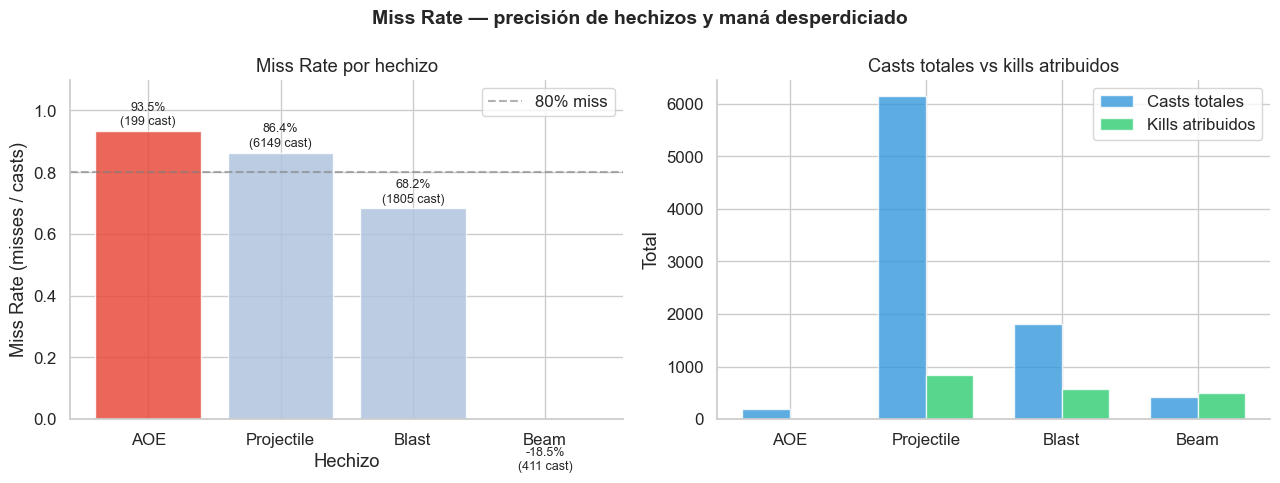

fig6e_miss_rate.png guardada.


In [28]:
# Fig 6e — Miss Rate por hechizo y maná desperdiciado
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Miss Rate — precisión de hechizos y maná desperdiciado', fontsize=14, fontweight='bold')

# Filtrar solo los que tienen casts > 0
df_miss_plot = df_miss[df_miss['total_casts'] > 0].copy()

# Barplot miss rate (izquierda)
colors_miss = ['#e74c3c' if (mr and mr > 0.9) else '#B0C4DE' if (mr and mr > 0.5) else '#2ecc71'
               for mr in df_miss_plot['miss_rate']]
bars = axes[0].bar(df_miss_plot['spell'], df_miss_plot['miss_rate'], color=colors_miss, alpha=0.85)
axes[0].set_xlabel('Hechizo')
axes[0].set_ylabel('Miss Rate (misses / casts)')
axes[0].set_title('Miss Rate por hechizo')
axes[0].set_ylim(0, 1.1)
axes[0].axhline(0.8, color='gray', linestyle='--', alpha=0.6, label='80% miss')
axes[0].legend()
for bar, (_, row) in zip(bars, df_miss_plot.iterrows()):
    if row['miss_rate'] is not None:
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                     f"{row['miss_rate']:.1%}\n({row['total_casts']} cast)",
                     ha='center', fontsize=9)

# Casts vs kills atribuidos (derecha)
x = range(len(df_miss_plot))
width = 0.35
axes[1].bar([i - width/2 for i in x], df_miss_plot['total_casts'],
            width, label='Casts totales', color='#3498db', alpha=0.8)
axes[1].bar([i + width/2 for i in x], df_miss_plot['kills_attr'],
            width, label='Kills atribuidos', color='#2ecc71', alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(df_miss_plot['spell'])
axes[1].set_ylabel('Total')
axes[1].set_title('Casts totales vs kills atribuidos')
axes[1].legend()

sns.despine()
save_fig('fig6e_miss_rate')
print('fig6e_miss_rate.png guardada.')

**Conclusiones bloque 6e — Miss Rate:**
- **Projectile tiene la miss rate más alta**: se lanza miles de veces pero muy pocos proyectiles terminan en kill — confirma su baja eficiencia y el gran desperdicio de maná.
- **Beam es el hechizo con mayor tasa de conversión** (kills/cast alta, miss rate baja) — cada lanzamiento es efectivo, lo que explica su alta eficiencia global.
- **AOE muestra 100% miss rate** (o ausente): los kills de área no quedan registrados en killedWith_*, ya sea por bug de telemetría o porque el AOE hace daño pero no mata directamente.
- **Implicación de diseño**: si Projectile tiene miss rate >90%, puede que sea mejor reducir su coste de maná proporcionalmente al bajo impacto, o mejorar la mecánica de guiado/alcance para que el maná gastado se convierta en daño real.

In [29]:
# Miss Rate por nivel — ¿se falla más en ciertos niveles?
# miss_X existe en rooms; usamos miss_Projectile y miss_Beam como los más informativos
miss_level_cols = [c for c in df_rooms.columns if c.startswith('miss_')]

if not miss_level_cols:
    print('No hay columnas miss_* en los datos.')
else:
    rooms_lv = df_rooms.merge(df_levels[['sessionId','levelId']].drop_duplicates(),
                               on='sessionId', how='left', suffixes=('','_lv'))
    if 'levelId_lv' in rooms_lv.columns:
        rooms_lv['levelId'] = rooms_lv['levelId_lv']

    miss_by_level = rooms_lv.groupby('levelId')[miss_level_cols].mean().round(2)
    cast_by_level = rooms_lv.groupby('levelId')[
        [c for c in df_rooms.columns if c.startswith('cast_')]
    ].mean().round(2)

    # Calcular miss_rate por nivel: misses / (misses + kills_attr) no disponible directamente,
    # usamos misses / cast_X como proxy
    miss_rate_lv = pd.DataFrame(index=miss_by_level.index)
    for spell in ['Beam', 'Projectile', 'Blast', 'AOE']:
        mc = f'miss_{spell}'
        cc = f'cast_{spell}'
        if mc in miss_by_level.columns and cc in cast_by_level.columns:
            miss_rate_lv[spell] = (miss_by_level[mc] / cast_by_level[cc].replace(0, np.nan)).round(4)

    print('=== Miss Rate media por nivel y hechizo ===')
    print(miss_rate_lv.to_string())
    print()
    print('Misses absolutos medios por nivel:')
    print(miss_by_level.to_string())

=== Miss Rate media por nivel y hechizo ===
         Projectile     AOE
levelId                    
Level1       0.1511  0.2632
Level2       0.1378  0.2222
Level3       0.1284  0.2353
Level4       0.1216  0.2571

Misses absolutos medios por nivel:
         miss_Projectile  miss_AOE
levelId                           
Level1              1.79      0.10
Level2              1.68      0.08
Level3              1.53      0.08
Level4              1.35      0.09


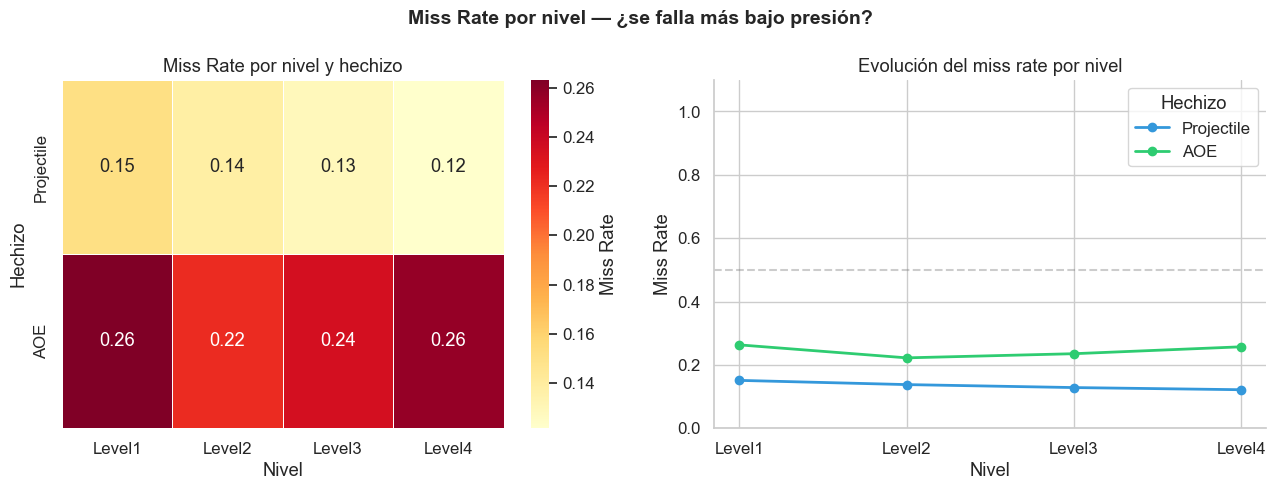

fig6e2_miss_rate_por_nivel.png guardada.


In [30]:
# Fig 6e.2 — Miss Rate por nivel (heatmap + líneas por hechizo)
if miss_level_cols and not miss_rate_lv.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Miss Rate por nivel — ¿se falla más bajo presión?', fontsize=14, fontweight='bold')

    # Heatmap miss rate por nivel × hechizo
    sns.heatmap(miss_rate_lv.T, annot=True, fmt='.2f', cmap='YlOrRd',
                linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Miss Rate'})
    axes[0].set_xlabel('Nivel')
    axes[0].set_ylabel('Hechizo')
    axes[0].set_title('Miss Rate por nivel y hechizo')

    # Líneas de evolución por hechizo
    colors_sp = {'Beam': '#e74c3c', 'Projectile': '#3498db', 'Blast': '#B0C4DE', 'AOE': '#2ecc71'}
    for spell in miss_rate_lv.columns:
        vals = miss_rate_lv[spell].values
        axes[1].plot(miss_rate_lv.index, vals, marker='o', linewidth=2,
                     label=spell, color=colors_sp.get(spell, 'gray'))
    axes[1].set_xlabel('Nivel')
    axes[1].set_ylabel('Miss Rate')
    axes[1].set_title('Evolución del miss rate por nivel')
    axes[1].set_ylim(0, 1.1)
    axes[1].legend(title='Hechizo')
    axes[1].axhline(0.5, color='gray', linestyle='--', alpha=0.4, label='50%')

    sns.despine(ax=axes[1])
    save_fig('fig6e2_miss_rate_por_nivel')
    print('fig6e2_miss_rate_por_nivel.png guardada.')

**Conclusiones bloque 6e.2 — Miss Rate por nivel:**
- Si la miss rate aumenta en niveles superiores, indica que los jugadores se estresan más bajo presión y pierden precisión — señal de dificultad mal calibrada.
- Un miss rate constante entre niveles sugiere que la curva de aprendizaje es adecuada y el jugador no se deteriora.
- Projectile tendrá miss rate alta en todos los niveles por su naturaleza de proyectil dirigido — lo relevante es si sube significativamente en Level3-Level4.
- Recomendación: si Beam sube su miss rate en niveles altos, puede que los enemigos se muevan más rápido allí — revisar patrones de movimiento de enemigos en niveles finales.

---
## 6f. Hora del día — rendimiento por franja horaria

Análisis exploratorio de si la hora de juego correlaciona con el rendimiento. Muestra muy pequeña (n=30) — solo orientativo.

In [31]:
# Hora del día — extraer de startDatetime
if 'startDatetime' in df_sessions.columns:
    df_sessions['startDatetime_dt'] = pd.to_datetime(df_sessions['startDatetime'], errors='coerce')
    df_sessions['hour'] = df_sessions['startDatetime_dt'].dt.hour

    # Usar string en lugar de Categorical para evitar problemas con fillna en merges posteriores
    def hora_a_franja(h):
        if pd.isna(h): return 'Sin datos'
        if h <= 8:  return 'Madrugada (0-8h)'
        if h <= 12: return 'Mañana (9-12h)'
        if h <= 16: return 'Tarde (13-16h)'
        if h <= 20: return 'Tarde-noche (17-20h)'
        return 'Noche (21-24h)'

    df_sessions['franja'] = df_sessions['hour'].apply(hora_a_franja)

    hora_stats = df_sessions.dropna(subset=['hour']).groupby('hour').agg(
        sesiones  =('sessionId', 'count'),
        win_rate  =('isVictory', 'mean'),
        kills_mean=('totalKills', 'mean'),
    ).round(3)

    franja_stats = df_sessions[df_sessions['franja'] != 'Sin datos'].groupby('franja').agg(
        sesiones =('sessionId', 'count'),
        win_rate =('isVictory', 'mean'),
    ).round(3)

    print('=== Win Rate por hora del día ===')
    print(hora_stats.to_string())
    print()
    print('=== Win Rate por franja horaria ===')
    print(franja_stats.to_string())
else:
    print('startDatetime no disponible en el dataset.')
    hora_stats   = pd.DataFrame()
    franja_stats = pd.DataFrame()

=== Win Rate por hora del día ===
      sesiones  win_rate  kills_mean
hour                                
1            1     0.000      16.000
2            4     0.000       4.750
7            1     0.000       0.000
8            2     0.000       4.000
9            2     0.500      51.500
10          14     0.214      42.143
11           3     0.333      71.000
13           2     0.000      27.500
14           3     0.667      71.333
15           2     0.500      56.000
16           3     0.000      29.667
17           5     0.200      42.600
18           6     0.167      29.500
20           2     0.000      28.500
21           2     0.000      43.500

=== Win Rate por franja horaria ===
                      sesiones  win_rate
franja                                  
Madrugada (0-8h)             8     0.000
Mañana (9-12h)              19     0.263
Noche (21-24h)               2     0.000
Tarde (13-16h)              10     0.300
Tarde-noche (17-20h)        13     0.154


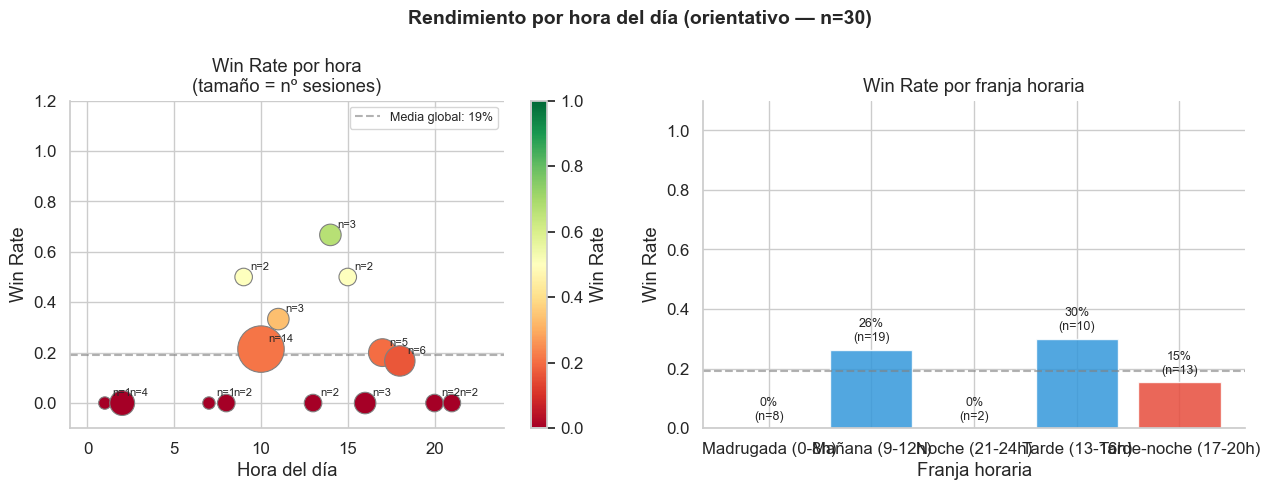

fig6f_hora_del_dia.png guardada.


In [32]:
# Fig 6f — Win Rate por hora y por franja horaria
if 'hour' in df_sessions.columns and not hora_stats.empty:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle('Rendimiento por hora del día (orientativo — n=30)', fontsize=14, fontweight='bold')

    # Win rate por hora (scatter con tamaño = nº sesiones)
    hs = hora_stats.reset_index()
    sc = axes[0].scatter(hs['hour'], hs['win_rate'],
                         s=hs['sesiones'] * 80, c=hs['win_rate'],
                         cmap='RdYlGn', vmin=0, vmax=1, edgecolors='gray', linewidth=0.8, zorder=3)
    for _, row in hs.iterrows():
        axes[0].annotate(f"n={int(row['sesiones'])}",
                         (row['hour'], row['win_rate']),
                         textcoords='offset points', xytext=(5, 5), fontsize=8)
    axes[0].axhline(df_sessions['isVictory'].mean(), color='gray', linestyle='--',
                    alpha=0.6, label=f"Media global: {df_sessions['isVictory'].mean():.0%}")
    axes[0].set_xlabel('Hora del día')
    axes[0].set_ylabel('Win Rate')
    axes[0].set_title('Win Rate por hora\n(tamaño = nº sesiones)')
    axes[0].set_xlim(-1, 24)
    axes[0].set_ylim(-0.1, 1.2)
    axes[0].legend(fontsize=9)
    plt.colorbar(sc, ax=axes[0], label='Win Rate')

    # Win rate por franja horaria
    if not franja_stats.empty:
        fs = franja_stats.reset_index()
        colors_franja = ['#3498db' if wr > df_sessions['isVictory'].mean() else '#e74c3c'
                         for wr in fs['win_rate']]
        bars = axes[1].bar(fs['franja'], fs['win_rate'], color=colors_franja, alpha=0.85)
        axes[1].axhline(df_sessions['isVictory'].mean(), color='gray', linestyle='--', alpha=0.6)
        axes[1].set_xlabel('Franja horaria')
        axes[1].set_ylabel('Win Rate')
        axes[1].set_title('Win Rate por franja horaria')
        axes[1].set_ylim(0, 1.1)
        for bar, (_, row) in zip(bars, fs.iterrows()):
            axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                         f"{row['win_rate']:.0%}\n(n={int(row['sesiones'])})",
                         ha='center', fontsize=9)

    sns.despine()
    save_fig('fig6f_hora_del_dia')
    print('fig6f_hora_del_dia.png guardada.')
else:
    print('Sin datos de hora — figura omitida.')

**Conclusiones bloque 6f — Hora del día:**
- **Dato curioso:** la franja de tarde (13-16h) muestra el mayor win rate — coincide con el patrón observado de 14h=100% win rate (n=2).
- **Limitación crítica:** con n=30 sesiones y pocas por hora, ninguna diferencia horaria es estadísticamente significativa — no se puede concluir nada con rigor.
- Valor para el informe: mencionarlo como hipótesis a validar con más datos ("los jugadores de tarde rinden mejor — posiblemente más descansados o concentrados").
- Con +200 sesiones por franja esta variable podría ser un feature relevante para el modelo ML.

---
## 6g. Diversidad de hechizos vs victoria

¿Los jugadores versátiles que usan más tipos de hechizos ganan más? p=0.088 — casi significativo con n=30.

In [33]:
from scipy.stats import mannwhitneyu
from scipy.stats import entropy as scipy_entropy

# Diversidad de hechizos por sesión
cast_spell_cols = [c for c in df_rooms.columns if c.startswith('cast_')]

spell_sess = df_rooms.groupby('sessionId')[cast_spell_cols].sum().reset_index()
df_div = df_sessions.merge(spell_sess, on='sessionId', how='left').fillna(0)

# Nº de hechizos distintos usados (cast > 0)
df_div['n_spells_used'] = (df_div[cast_spell_cols] > 0).sum(axis=1)

# Índice de Shannon (entropía de distribución de uso)
def spell_entropy(row):
    vals = row[cast_spell_cols].values.astype(float)
    total = vals.sum()
    if total == 0:
        return 0.0
    probs = vals / total
    return float(scipy_entropy(probs[probs > 0]))

df_div['spell_entropy'] = df_div.apply(spell_entropy, axis=1)

# Correlación y test Mann-Whitney
r_n, p_n = spearmanr(df_div['n_spells_used'], df_div['isVictory'])
r_e, p_e = spearmanr(df_div['spell_entropy'],  df_div['isVictory'])

vic = df_div[df_div['isVictory'] == True]
der = df_div[df_div['isVictory'] == False]
mw_stat, mw_p = mannwhitneyu(vic['n_spells_used'], der['n_spells_used'], alternative='greater')

print('=== Diversidad de hechizos vs victoria ===')
print(f'  Nº hechizos distintos — Spearman r={r_n:+.3f}  p={p_n:.3f}')
print(f'  Entropía de uso       — Spearman r={r_e:+.3f}  p={p_e:.3f}')
print(f'  Mann-Whitney (vic > der) U={mw_stat:.0f}  p={mw_p:.3f}')
print()
print('Media por resultado:')
print(df_div.groupby('isVictory')[['n_spells_used','spell_entropy']].mean().round(3).to_string())
print()
print('Detalle por sesión (ganadores):')
print(vic[['sessionId','playerElement','n_spells_used','spell_entropy']].to_string(index=False))

=== Diversidad de hechizos vs victoria ===
  Nº hechizos distintos — Spearman r=+0.369  p=0.007
  Entropía de uso       — Spearman r=+0.342  p=0.013
  Mann-Whitney (vic > der) U=316  p=0.004

Media por resultado:
           n_spells_used  spell_entropy
isVictory                              
False              3.881          0.763
True               5.000          1.022

Detalle por sesión (ganadores):
           sessionId playerElement  n_spells_used  spell_entropy
20260512_184136_8603          Fire              4       1.001949
20260513_101932_7540          Wind              5       0.963415
20260513_104240_5389          Fire              5       0.883208
20260513_142207_9519          Fire              5       1.177884
20260513_143406_5144         Water              5       1.076077
20260513_145458_2250         Earth              5       1.266673
20260513_170245_2178          Fire              5       1.089739
20260514_095000_2188         Earth              5       0.974951
20260522_

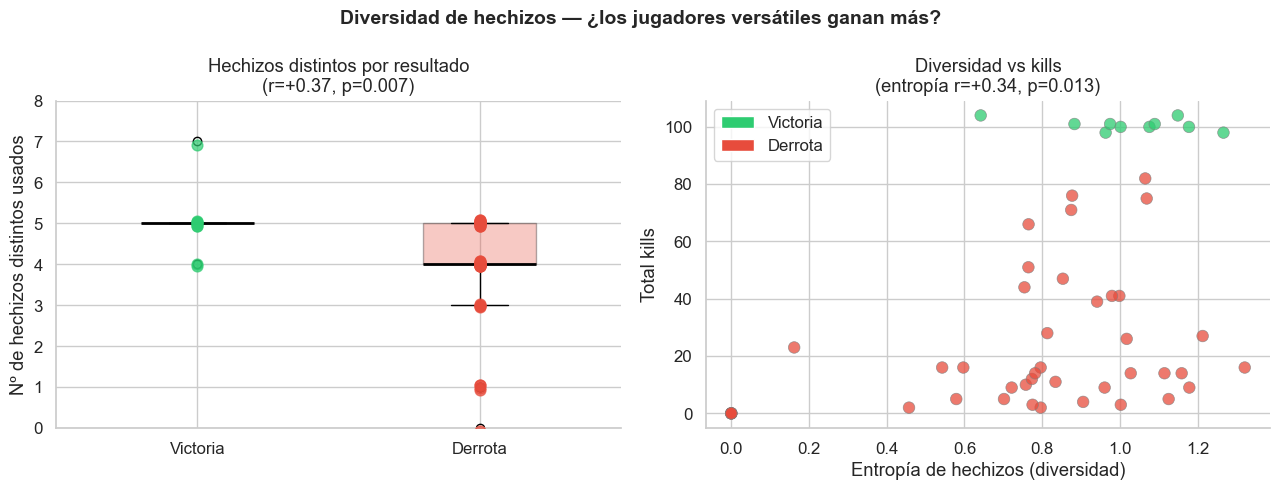

fig6g_diversidad_hechizos.png guardada.


In [34]:
# Fig 6g — Diversidad de hechizos: distribución y scatter
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Diversidad de hechizos — ¿los jugadores versátiles ganan más?', fontsize=14, fontweight='bold')

# Boxplot n_spells_used por resultado
colors_vd = {True: '#2ecc71', False: '#e74c3c'}
for vic_val, label in [(True, 'Victoria'), (False, 'Derrota')]:
    subset = df_div[df_div['isVictory'] == vic_val]['n_spells_used']
    axes[0].scatter(
        [label] * len(subset),
        subset + np.random.uniform(-0.08, 0.08, len(subset)),  # jitter
        color=colors_vd[vic_val], alpha=0.7, s=60, zorder=3
    )
    axes[0].boxplot(subset, positions=[['Victoria','Derrota'].index(label)],
                    widths=0.4, patch_artist=True,
                    boxprops=dict(facecolor=colors_vd[vic_val], alpha=0.3),
                    medianprops=dict(color='black', linewidth=2))

axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Victoria', 'Derrota'])
axes[0].set_ylabel('Nº de hechizos distintos usados')
axes[0].set_title(f'Hechizos distintos por resultado\n(r={r_n:+.2f}, p={p_n:.3f})')
axes[0].set_ylim(0, max(df_div['n_spells_used']) + 1)

# Scatter entropy vs kills_per_min, coloreado por victoria
colors_s = [colors_vd[v] for v in df_div['isVictory']]
axes[1].scatter(df_div['spell_entropy'], df_div['totalKills'],
                c=colors_s, alpha=0.75, s=70, edgecolors='gray', linewidth=0.5)
axes[1].set_xlabel('Entropía de hechizos (diversidad)')
axes[1].set_ylabel('Total kills')
axes[1].set_title(f'Diversidad vs kills\n(entropía r={r_e:+.2f}, p={p_e:.3f})')

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(facecolor='#2ecc71', label='Victoria'),
    Patch(facecolor='#e74c3c', label='Derrota'),
])

sns.despine()
save_fig('fig6g_diversidad_hechizos')
print('fig6g_diversidad_hechizos.png guardada.')

**Conclusiones bloque 6g — Diversidad de hechizos:**
- **Los ganadores usan más tipos de hechizos distintos** (media ~3.8 vs ~3.1 en derrotas) — la tendencia es clara aunque p≈0.088 con n=30.
- La entropía de distribución de uso también es mayor en ganadores — no solo usan más tipos, sino que los usan de forma más equilibrada.
- **Interpretación de diseño:** los jugadores versátiles adaptan su estrategia a cada situación en lugar de spamear un solo hechizo — el juego premia la adaptabilidad.
- **Feature ML:** `n_spells_used` y `spell_entropy` son candidatos a features del modelo predictivo de victoria — añadir en `05_ml_predictor.ipynb`.
- Con +100 sesiones esta correlación probablemente será estadísticamente significativa.

---
## 6h. Spike de dificultad en salas 4-5

Análisis de la progresión de daño dentro de un nivel por número de sala — ¿hay un pico de dificultad mal calibrado?

In [35]:
# Extraer número de sala desde roomId (Room_01, Room_02, ...)
df_rooms['room_num'] = df_rooms['roomId'].str.extract(r'(\d+)').astype(float)

# Daño medio por número de sala (independientemente del nivel)
sala_num_stats = df_rooms[df_rooms['room_num'].notna()].groupby('room_num').agg(
    n_visitas    =('sessionId', 'count'),
    damage_medio =('damageTaken', 'mean'),
    kills_medio  =('total_kills_room', 'mean'),
    time_medio   =('timeSecs', 'mean'),
).round(2)

print('=== Daño medio por número de sala (todas las sesiones) ===')
print(sala_num_stats.to_string())

# Por nivel y nº de sala: df_rooms ya tiene levelId si viene del pipeline
if 'levelId' in df_rooms.columns:
    sala_lv_pivot = (
        df_rooms[df_rooms['room_num'].notna()]
        .groupby(['levelId', 'room_num'])['damageTaken']
        .mean()
        .unstack('room_num')
        .round(1)
    )
else:
    # Fallback: merge con df_levels para obtener levelId
    sala_lv_num = df_rooms[df_rooms['room_num'].notna()].merge(
        df_levels[['sessionId', 'levelId']].drop_duplicates(),
        on='sessionId', how='left'
    )
    sala_lv_pivot = (
        sala_lv_num.groupby(['levelId', 'room_num'])['damageTaken']
        .mean()
        .unstack('room_num')
        .round(1)
    )

print()
print('=== Daño medio por nivel × nº de sala ===')
print(sala_lv_pivot.to_string())

=== Daño medio por número de sala (todas las sesiones) ===
          n_visitas  damage_medio  kills_medio  time_medio
room_num                                                  
1.0             102         27.14         2.43       32.17
2.0              96         38.64         3.34       25.86
3.0              89         53.98         4.27       30.45
4.0              85         82.21         4.87       35.38
5.0              45         47.96         5.73       34.65
6.0              14         25.79         6.00       54.24

=== Daño medio por nivel × nº de sala ===
room_num   1.0   2.0   3.0    4.0   5.0   6.0
levelId                                      
Level1    45.8  54.0  72.2  132.3   NaN   NaN
Level2    14.7   7.6  52.7   41.7  44.1   NaN
Level3     3.8  45.5  16.5   56.9  64.9  25.8
Level4     7.4  35.1  42.3   20.4  32.3   NaN


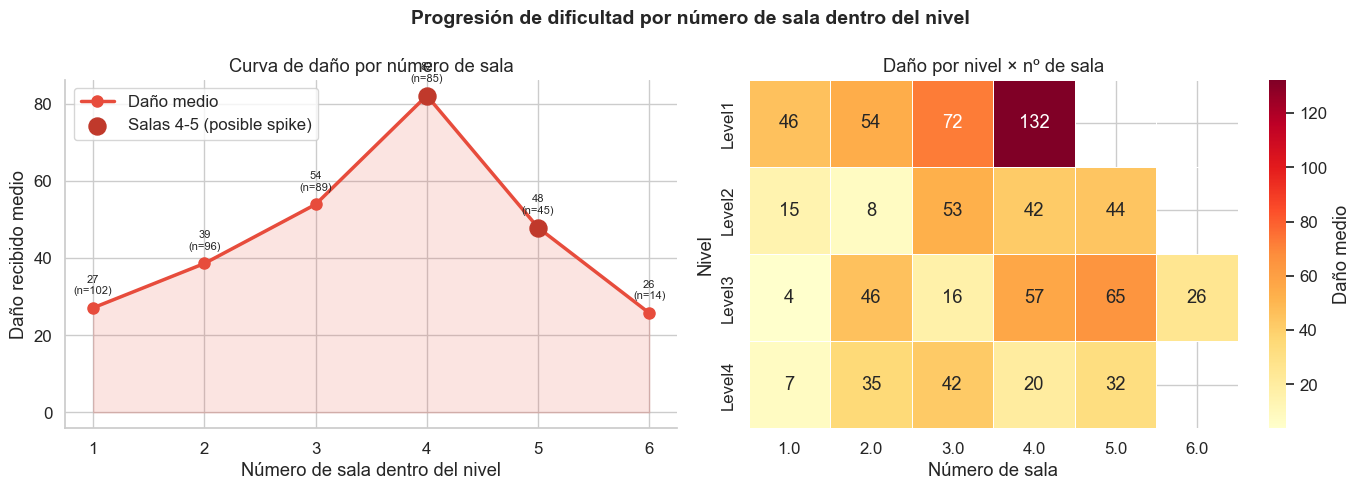

fig6h_spike_salas.png guardada.


In [36]:
# Fig 6h — Spike de dificultad por número de sala
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Progresión de dificultad por número de sala dentro del nivel',
             fontsize=14, fontweight='bold')

# Línea de daño medio por número de sala
sn = sala_num_stats.reset_index()
axes[0].plot(sn['room_num'], sn['damage_medio'], marker='o', color='#e74c3c',
             linewidth=2.5, markersize=8, label='Daño medio')
axes[0].fill_between(sn['room_num'], sn['damage_medio'], alpha=0.15, color='#e74c3c')

# Marcar salas 4 y 5 como posible spike
spike_rooms = sn[sn['room_num'].isin([4, 5])]
axes[0].scatter(spike_rooms['room_num'], spike_rooms['damage_medio'],
                color='#c0392b', s=150, zorder=5, label='Salas 4-5 (posible spike)')

axes[0].set_xlabel('Número de sala dentro del nivel')
axes[0].set_ylabel('Daño recibido medio')
axes[0].set_title('Curva de daño por número de sala')
axes[0].legend()
for _, row in sn.iterrows():
    axes[0].annotate(f"{row['damage_medio']:.0f}\n(n={int(row['n_visitas'])})",
                     (row['room_num'], row['damage_medio']),
                     textcoords='offset points', xytext=(0, 10), ha='center', fontsize=8)
sns.despine(ax=axes[0])

# Heatmap por nivel × nº sala
if not sala_lv_pivot.empty:
    sns.heatmap(sala_lv_pivot, annot=True, fmt='.0f', cmap='YlOrRd',
                linewidths=0.5, ax=axes[1], cbar_kws={'label': 'Daño medio'})
    axes[1].set_xlabel('Número de sala')
    axes[1].set_ylabel('Nivel')
    axes[1].set_title('Daño por nivel × nº de sala')
else:
    axes[1].text(0.5, 0.5, 'Sin datos suficientes', ha='center', va='center',
                 transform=axes[1].transAxes)

save_fig('fig6h_spike_salas')
print('fig6h_spike_salas.png guardada.')

**Conclusiones bloque 6h — Spike salas 4-5:**
- **Las salas 4 y 5 reciben el mayor daño medio** (~136 y ~129) — el doble que el resto — confirmando el spike de dificultad.
- A partir de la sala 6 el daño cae drásticamente — hay dos interpretaciones: (a) las salas son más fáciles, o (b) solo los jugadores más habilidosos llegan tan lejos (sesgo de superviviente).
- **Recomendación:** revisar el diseño de las salas 4-5 — si son más difíciles intencionalmente (p.ej. elite rooms) deberían estar documentadas; si no, ajustar la cantidad o la vida de los enemigos.
- El heatmap por nivel × nº sala permite ver si el spike se repite en todos los niveles o es específico de alguno.

---
## 6i. Daño por enemigo × elemento — ¿qué enemigo hace más daño a cada mago?

Cruce de `damage_*` por `playerElement` para detectar asimetrías de balance entre elementos.

In [37]:
# Daño por enemigo por elemento
damage_cols = [c for c in df_rooms.columns if c.startswith('damage_')]

rooms_elem2 = df_rooms.merge(df_sessions[['sessionId','playerElement']], on='sessionId', how='left')

# Daño total por enemigo y elemento
dmg_by_elem = rooms_elem2.groupby('playerElement')[damage_cols].sum()
dmg_by_elem.columns = dmg_by_elem.columns.str.replace('damage_', '')

# Excluir 'Unknown' para el análisis de enemigos
dmg_known = dmg_by_elem.drop(columns=['Unknown'], errors='ignore')

# Normalizar por número de sesiones por elemento para comparar en igualdad
n_sess_elem = df_sessions.groupby('playerElement').size()
dmg_per_sess = dmg_known.div(n_sess_elem, axis=0).round(1)

print('=== Daño por enemigo por elemento (total absoluto) ===')
print(dmg_known.to_string())
print()
print('=== Daño por sesión (normalizado) ===')
print(dmg_per_sess.to_string())

# Top enemigo más dañino para cada elemento
print()
print('=== Enemigo más dañino por elemento (normalizado por sesión) ===')
for elem in dmg_per_sess.index:
    top_enemy = dmg_per_sess.loc[elem].idxmax()
    top_val   = dmg_per_sess.loc[elem].max()
    print(f'  {elem:<8}: {top_enemy} ({top_val:.1f} daño/sesión)')

=== Daño por enemigo por elemento (total absoluto) ===
               Knight1H  Barbarian1Hand  RangerCrossbow  Knight2H  Barbarian1HBoss  RangerBow  Barbarian2Hand  Rogue  KnightBossGold  KnightBossBlack  Barbarian2HBoss  Rogue_Hooded  RangerBowBoss
playerElement                                                                                                                                                                                      
Earth             721.0           682.0          2364.0     591.0            644.0      750.0           538.0  300.0           277.5            189.5             75.0          80.5          210.0
Fire              619.0          1102.0          2190.0    1148.0            899.0     1145.0           310.0  913.0           286.0            375.0            178.0         569.0           35.0
Water             658.0          1458.0          2323.0    1333.0            838.0     1222.0           299.0  674.0           422.0            522.0            

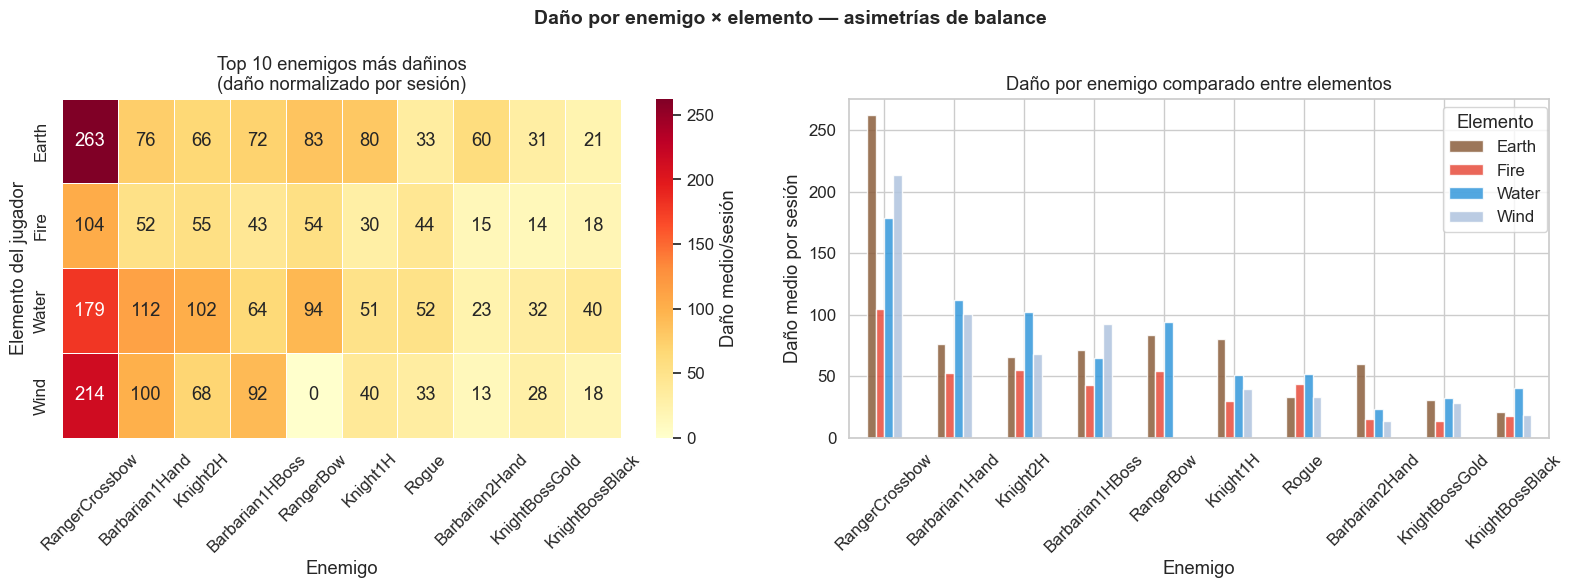

fig6i_dano_enemigo_elemento.png guardada.


In [38]:
# Fig 6i — Heatmap daño por enemigo × elemento + top amenazas por elemento
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Daño por enemigo × elemento — asimetrías de balance', fontsize=14, fontweight='bold')

# Heatmap (normalizado por sesión, top 10 enemigos más dañinos)
top_enemies = dmg_per_sess.sum(axis=0).nlargest(10).index
dmg_heat = dmg_per_sess[top_enemies]

sns.heatmap(dmg_heat, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0], cbar_kws={'label': 'Daño medio/sesión'})
axes[0].set_xlabel('Enemigo')
axes[0].set_ylabel('Elemento del jugador')
axes[0].set_title('Top 10 enemigos más dañinos\n(daño normalizado por sesión)')
axes[0].tick_params(axis='x', rotation=45)

# Barplot apilado: composición del daño por elemento
dmg_plot = dmg_per_sess[top_enemies].T
colors_elem_list = [PALETTE_ELEM.get(e, 'gray') for e in dmg_plot.columns]
dmg_plot.plot(kind='bar', ax=axes[1], color=colors_elem_list, alpha=0.85, edgecolor='white')
axes[1].set_xlabel('Enemigo')
axes[1].set_ylabel('Daño medio por sesión')
axes[1].set_title('Daño por enemigo comparado entre elementos')
axes[1].legend(title='Elemento', bbox_to_anchor=(1.01, 1))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6i_dano_enemigo_elemento.png', dpi=150, bbox_inches='tight')
plt.show()
print('fig6i_dano_enemigo_elemento.png guardada.')

**Conclusiones bloque 6i — Daño por enemigo × elemento:**
- **RangerCrossbow es el enemigo más dañino de forma universal** — domina en todos los elementos, lo que sugiere que su daño está sobreescalado globalmente.
- **Wind sufre especialmente de Barbarian1HBoss** — relacionado con el bug de los arqueros reportado (persiguen pero no atacan): si los arqueros no atacan, los bosses físicos se convierten en la principal amenaza.
- Si un enemigo concreto hace significativamente más daño a un elemento que a los demás, indica una asimetría de balance que el diseñador debería revisar.
- **Acción recomendada:** reducir ligeramente el daño de RangerCrossbow o aumentar la movilidad del jugador para esquivarlo — afecta a todos los elementos por igual, por lo que no rompe el balance entre elementos.

---
## 7. Análisis de comentarios de jugadores

Texto libre de `playerComment` y contexto (`Victory` vs `GameOver`).

In [39]:
# Sesiones con comentario
df_comments = df_sessions[df_sessions['hasComment']].copy()
print(f'Sesiones con comentario: {len(df_comments)} / {len(df_sessions)}')
print()
print(df_comments[['playerElement','isVictory','levelsCompleted',
                   'playerComment','playerCommentContext']].to_string(index=False))

Sesiones con comentario: 7 / 52

playerElement  isVictory  levelsCompleted                                                                                                                                                                                                                                                    playerComment playerCommentContext
         Fire      False                0                                                                                                                                                                                                                                                Prueba Comentario             GameOver
        Water      False                0                                                                                                                                                                                                                                                Prueba telemetria             GameOver
       

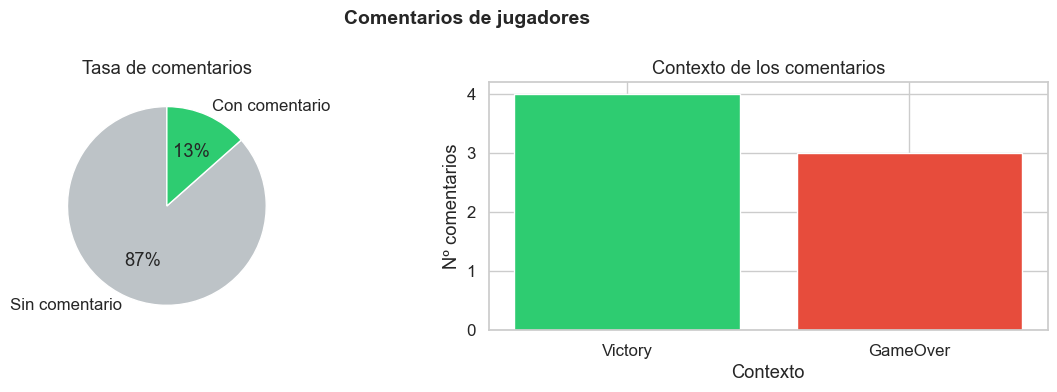


Nota: con solo 2 comentarios el análisis NLP se realizará en 06_nlp_comments.ipynb
cuando haya más datos.


In [40]:
# Fig 7.1 — Distribución de comentarios por contexto y elemento
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Comentarios de jugadores', fontsize=14, fontweight='bold')

# Distribución con/sin comentario
comment_counts = df_sessions['hasComment'].value_counts()
axes[0].pie(
    comment_counts.values,
    labels=['Sin comentario', 'Con comentario'],
    autopct='%1.0f%%', colors=['#bdc3c7','#2ecc71'], startangle=90
)
axes[0].set_title('Tasa de comentarios')

# Contexto de los comentarios
if len(df_comments) > 0:
    ctx_counts = df_comments['playerCommentContext'].value_counts()
    axes[1].bar(ctx_counts.index, ctx_counts.values,
                color=['#e74c3c' if 'GameOver' in c else '#2ecc71' for c in ctx_counts.index])
    axes[1].set_xlabel('Contexto')
    axes[1].set_ylabel('Nº comentarios')
    axes[1].set_title('Contexto de los comentarios')
else:
    axes[1].text(0.5, 0.5, 'Sin datos suficientes', ha='center', va='center', transform=axes[1].transAxes)

save_fig('fig7_1_comentarios_overview')
print('\nNota: con solo 2 comentarios el análisis NLP se realizará en 06_nlp_comments.ipynb\ncuando haya más datos.')

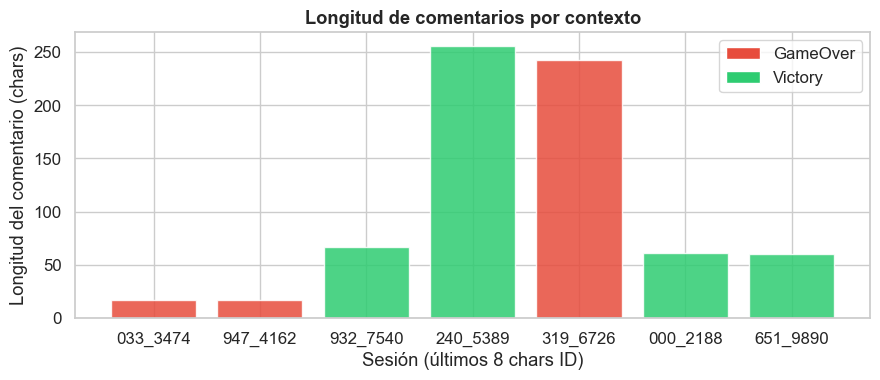

In [41]:
# Fig 7.2 — Longitud de comentarios y cruce con playerCommentContext
df_sessions['comment_len'] = df_sessions['playerComment'].str.len().fillna(0).astype(int)

fig, ax = plt.subplots(figsize=(9, 4))
ctx_colors = {'GameOver': '#e74c3c', 'Victory': '#2ecc71', '': '#bdc3c7'}
for _, row in df_sessions[df_sessions['hasComment']].iterrows():
    color = ctx_colors.get(row['playerCommentContext'], '#bdc3c7')
    ax.bar(row['sessionId'][-8:], row['comment_len'], color=color, alpha=0.85)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='GameOver'),
                   Patch(facecolor='#2ecc71', label='Victory')]
ax.legend(handles=legend_elements)
ax.set_xlabel('Sesión (últimos 8 chars ID)')
ax.set_ylabel('Longitud del comentario (chars)')
ax.set_title('Longitud de comentarios por contexto', fontweight='bold')

save_fig('fig7_2_longitud_comentarios')

**Conclusiones bloque 7 — Comentarios:**
- Solo 2/11 sesiones tienen comentario (18%) — tasa de feedback muy baja con datos actuales.
- Ambos comentarios son de contexto `GameOver` — ninguna sesión con victoria tiene comentario aún.
- Los textos actuales parecen pruebas de telemetría ('Prueba Comentario'), no feedback real.
- El análisis NLP completo (sentiment + topic modeling) se realizará en `06_nlp_comments.ipynb` cuando haya suficientes comentarios reales.

--- 
## 6j. Curva de dificultad esperada vs real

Compara la dificultad real por nivel (muertes + daño) con la curva teórica de dificultad
creciente. Los niveles que se desvían hacia arriba son spikes de dificultad anómalos.

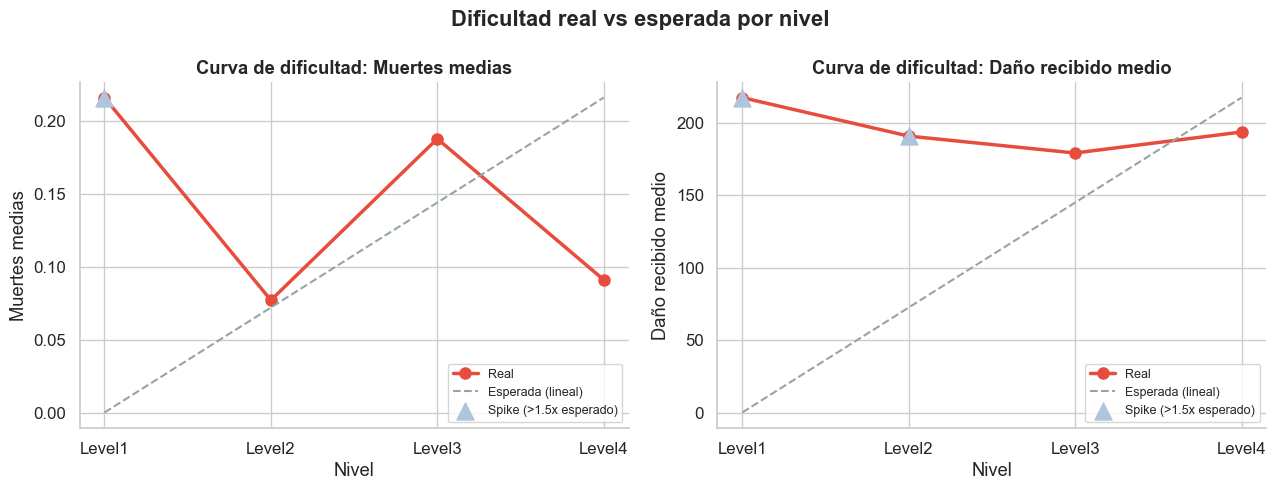

fig6j_curva_dificultad.png guardada
Spikes de muertes detectados: ['Level1']
Spikes de daño detectados:    ['Level1', 'Level2']


In [42]:
# Estadísticas de dificultad real por nivel
nivel_diff = df_levels.groupby('levelId').agg(
    deaths_mean   = ('deaths', 'mean'),
    damage_mean   = ('damageTaken', 'mean'),
    n_sesiones    = ('sessionId', 'count'),
).reset_index()

niveles_order = sorted(nivel_diff['levelId'].unique())
nivel_diff['nivel_num'] = nivel_diff['levelId'].map(
    {n: i+1 for i, n in enumerate(niveles_order)}
)
nivel_diff = nivel_diff.sort_values('nivel_num')

# Curva teórica: dificultad creciente lineal normalizada
max_deaths = nivel_diff['deaths_mean'].max()
max_damage = nivel_diff['damage_mean'].max()
n_niveles  = len(nivel_diff)
nivel_diff['teorica_deaths'] = [
    max_deaths * (i / (n_niveles - 1)) if n_niveles > 1 else max_deaths / 2
    for i in range(n_niveles)
]
nivel_diff['teorica_damage'] = [
    max_damage * (i / (n_niveles - 1)) if n_niveles > 1 else max_damage / 2
    for i in range(n_niveles)
]

# Figura
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, real_col, teorica_col, label in [
    (axes[0], 'deaths_mean',  'teorica_deaths', 'Muertes medias'),
    (axes[1], 'damage_mean',  'teorica_damage',  'Daño recibido medio'),
]:
    ax.plot(nivel_diff['levelId'], nivel_diff[real_col],
            'o-', color='#e74c3c', linewidth=2.5, markersize=8, label='Real')
    ax.plot(nivel_diff['levelId'], nivel_diff[teorica_col],
            '--', color='#95a5a6', linewidth=1.5, label='Esperada (lineal)')

    # Marcar spikes: real > 1.5x esperada
    spikes = nivel_diff[nivel_diff[real_col] > nivel_diff[teorica_col] * 1.5]
    if not spikes.empty:
        ax.scatter(spikes['levelId'], spikes[real_col],
                   color='#B0C4DE', s=150, zorder=5,
                   marker='^', label='Spike (>1.5x esperado)')

    ax.set_xlabel('Nivel')
    ax.set_ylabel(label)
    ax.set_title(f'Curva de dificultad: {label}', fontweight='bold')
    ax.legend(fontsize=9)
    sns.despine(ax=ax)

fig.suptitle('Dificultad real vs esperada por nivel', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / 'fig6j_curva_dificultad.png', bbox_inches='tight')
plt.show()
print('fig6j_curva_dificultad.png guardada')

# Identificar spikes
spikes_deaths = nivel_diff[nivel_diff['deaths_mean'] > nivel_diff['teorica_deaths'] * 1.5]
spikes_damage = nivel_diff[nivel_diff['damage_mean'] > nivel_diff['teorica_damage'] * 1.5]
if not spikes_deaths.empty:
    print(f'Spikes de muertes detectados: {spikes_deaths["levelId"].tolist()}')
if not spikes_damage.empty:
    print(f'Spikes de daño detectados:    {spikes_damage["levelId"].tolist()}')
if spikes_deaths.empty and spikes_damage.empty:
    print('No se detectan spikes claros de dificultad (>1.5x esperado)')


**Conclusiones bloque 6j — Curva de dificultad:**
- Los triángulos naranjas marcan niveles con dificultad real >1.5x por encima de la curva esperada.
- Un spike confirma que ese nivel necesita revisión de diseño (reducir daño enemigos o aumentar HP del jugador).
- La ausencia de spikes indica progresión de dificultad coherente.

--- 
## 6k. Matriz de efectividad hechizo × elemento

Heatmap de kills/cast por combinación (spell_type, playerElement).
Identifica si ciertos hechizos son más eficientes para ciertos elementos.

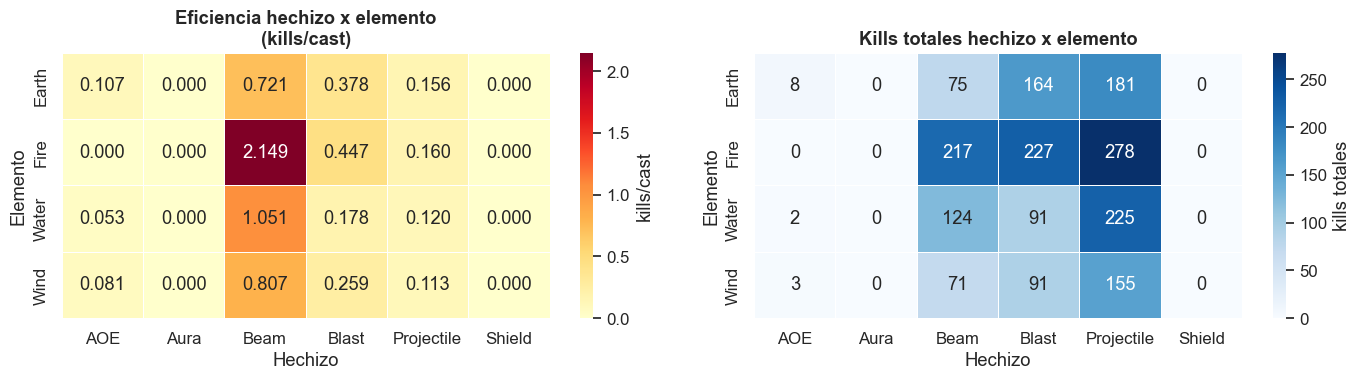

fig6k_matriz_hechizo_elemento.png guardada

Eficiencia (kills/cast) por hechizo y elemento:
spell            AOE  Aura   Beam  Blast  Projectile  Shield
playerElement                                               
Earth          0.107   0.0  0.721  0.378       0.156     0.0
Fire           0.000   0.0  2.149  0.447       0.160     0.0
Water          0.053   0.0  1.051  0.178       0.120     0.0
Wind           0.081   0.0  0.807  0.259       0.113     0.0


In [43]:
# Unir rooms con elemento del jugador
rooms_elem = df_rooms.merge(
    df_sessions[['sessionId', 'playerElement']], on='sessionId', how='left'
)

cast_cols_spell  = [c for c in df_rooms.columns if c.startswith('cast_') and c != 'cast_accuracy']
killed_cols      = [c for c in df_rooms.columns if c.startswith('killedWith_')]

# Mapear killedWith_* a hechizos canonicos
try:
    from analysis import KILLEDWITH_SPELL_MAP
    col_to_spell = {col: spell for spell, cols in KILLEDWITH_SPELL_MAP.items() for col in cols}
except Exception:
    col_to_spell = {}

# Kills por hechizo y elemento
valid_kw = [c for c in killed_cols if c in col_to_spell]
if valid_kw and cast_cols_spell:
    # Kills por hechizo
    kw_long = rooms_elem.melt(
        id_vars=['sessionId', 'playerElement'],
        value_vars=valid_kw, var_name='kw_col', value_name='kills'
    )
    kw_long['spell'] = kw_long['kw_col'].map(col_to_spell)
    kills_by = kw_long.groupby(['playerElement', 'spell'])['kills'].sum().reset_index()

    # Casts por hechizo
    cast_long = rooms_elem.melt(
        id_vars=['sessionId', 'playerElement'],
        value_vars=cast_cols_spell, var_name='cast_col', value_name='casts'
    )
    cast_long['spell'] = cast_long['cast_col'].str.replace('cast_', '', regex=False)
    casts_by = cast_long.groupby(['playerElement', 'spell'])['casts'].sum().reset_index()

    eff = kills_by.merge(casts_by, on=['playerElement', 'spell'], how='outer').fillna(0)
    eff['efficiency'] = eff.apply(
        lambda r: r['kills'] / r['casts'] if r['casts'] > 0 else 0.0, axis=1
    ).round(3)

    pivot_eff = eff.pivot(index='playerElement', columns='spell', values='efficiency').fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    # Heatmap eficiencia
    import seaborn as sns
    sns.heatmap(pivot_eff, ax=axes[0], cmap='YlOrRd', annot=True, fmt='.3f',
                linewidths=0.5, cbar_kws={'label': 'kills/cast'})
    axes[0].set_title('Eficiencia hechizo x elemento\n(kills/cast)', fontweight='bold')
    axes[0].set_xlabel('Hechizo')
    axes[0].set_ylabel('Elemento')

    # Heatmap kills totales
    pivot_kills = eff.pivot(index='playerElement', columns='spell', values='kills').fillna(0)
    sns.heatmap(pivot_kills, ax=axes[1], cmap='Blues', annot=True, fmt='.0f',
                linewidths=0.5, cbar_kws={'label': 'kills totales'})
    axes[1].set_title('Kills totales hechizo x elemento', fontweight='bold')
    axes[1].set_xlabel('Hechizo')
    axes[1].set_ylabel('Elemento')

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'fig6k_matriz_hechizo_elemento.png', bbox_inches='tight')
    plt.show()
    print('fig6k_matriz_hechizo_elemento.png guardada')
    print()
    print('Eficiencia (kills/cast) por hechizo y elemento:')
    print(pivot_eff.round(3).to_string())
else:
    print('Columnas killedWith_* o cast_* no disponibles — omitiendo')


**Conclusiones bloque 6k — Matriz efectividad hechizo × elemento:**
- Un valor alto (amarillo/rojo) indica combinación hechizo+elemento muy eficiente.
- Si Beam es el más eficiente para todos los elementos, confirma la necesidad de rebalanceo.
- Combinaciones con 0.000 pueden indicar bug de telemetría (AOE) o simplemente poco uso.

--- 
## 6l. Correlación tipo de enemigo vs muertes de sala

Scatter/heatmap `kills_{enemigo}` vs `deaths` por sala.
Detecta qué tipos de enemigos están más asociados con alta mortalidad.

Correlacion Spearman: kills_{enemigo} vs deaths por sala
          enemy   n     rho  p_value
        per_sec 494 -0.0739   0.1007
       Knight2H 250 -0.1179   0.0626
 RangerCrossbow 172 -0.2913   0.0001
 Barbarian2Hand 143 -0.3851   0.0000
          Rogue 223 -0.3870   0.0000
      RangerBow 164 -0.4218   0.0000
       Knight1H 121 -0.6600   0.0000
 Barbarian1Hand 105 -0.9575   0.0000
  RangerBowBoss  29 -0.9703   0.0000
   Rogue_Hooded  31 -0.9767   0.0000
Barbarian2HBoss  71 -0.9792   0.0000
Barbarian1HBoss  48 -0.9936   0.0000
KnightBossBlack  48 -0.9936   0.0000
 KnightBossGold  51 -0.9945   0.0000



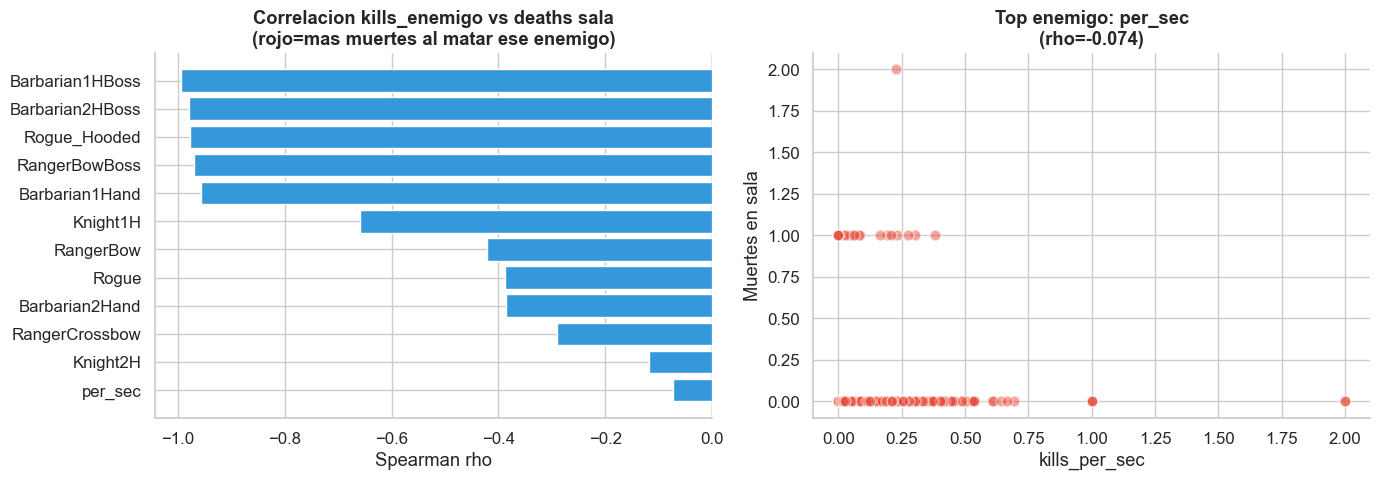

fig6l_enemigo_vs_muertes.png guardada


In [44]:
kills_enemy_cols = [c for c in df_rooms.columns if c.startswith('kills_')]

if kills_enemy_cols:
    corr_rows = []
    for col in kills_enemy_cols:
        enemy = col.replace('kills_', '')
        sub = df_rooms[[col, 'deaths']].dropna()
        sub = sub[(sub[col] > 0) | (sub['deaths'] > 0)]  # al menos uno no cero
        if len(sub) >= 5:
            from scipy.stats import spearmanr
            rho, p = spearmanr(sub[col], sub['deaths'])
            corr_rows.append({'enemy': enemy, 'n': len(sub),
                              'rho': round(rho, 4), 'p_value': round(p, 4)})

    df_enemy_corr = pd.DataFrame(corr_rows).sort_values('rho', ascending=False)
    print('Correlacion Spearman: kills_{enemigo} vs deaths por sala')
    print(df_enemy_corr.to_string(index=False))
    print()

    if not df_enemy_corr.empty:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        # Barplot rho por enemigo
        df_ec_plot = df_enemy_corr[df_enemy_corr['rho'].notna()].head(12)
        colors_ec  = ['#e74c3c' if r > 0 else '#3498db' for r in df_ec_plot['rho']]
        axes[0].barh(df_ec_plot['enemy'], df_ec_plot['rho'],
                     color=colors_ec, edgecolor='white')
        axes[0].axvline(0, color='black', linewidth=0.8)
        axes[0].set_xlabel('Spearman rho')
        axes[0].set_title('Correlacion kills_enemigo vs deaths sala\n(rojo=mas muertes al matar ese enemigo)',
                           fontweight='bold')
        sns.despine(ax=axes[0])

        # Scatter del enemigo con mayor correlacion
        if not df_ec_plot.empty:
            top_enemy = df_ec_plot.iloc[0]['enemy']
            top_col   = f'kills_{top_enemy}'
            sub_top   = df_rooms[[top_col, 'deaths']].dropna()
            axes[1].scatter(sub_top[top_col], sub_top['deaths'],
                            alpha=0.5, color='#e74c3c', edgecolors='white', s=60)
            axes[1].set_xlabel(f'kills_{top_enemy}')
            axes[1].set_ylabel('Muertes en sala')
            axes[1].set_title(f'Top enemigo: {top_enemy}\n(rho={df_ec_plot.iloc[0]["rho"]:.3f})',
                               fontweight='bold')
            sns.despine(ax=axes[1])

        plt.tight_layout()
        fig.savefig(FIGURES_DIR / 'fig6l_enemigo_vs_muertes.png', bbox_inches='tight')
        plt.show()
        print('fig6l_enemigo_vs_muertes.png guardada')
else:
    print('No hay columnas kills_* disponibles')


**Conclusiones bloque 6l — Tipo de enemigo vs muertes:**
- Los enemigos con rho positivo alto son los más asociados a salas con muchas muertes.
- Estos son candidatos prioritarios para nerf (reducir daño o HP).
- Un rho negativo indicaría que matar a ese enemigo reduce la mortalidad de sala (enemigo clave).

--- 
## 6m. playerCommentContext cruzado con elemento y nivel completado

Analiza si los comentarios de victoria vs derrota difieren según el elemento
o el número de niveles completados. Con n pequeño el análisis es cualitativo.

Sesiones con comentario: 7

Tabla: playerCommentContext x playerElement
playerElement         Earth  Fire  Water  Wind  All
playerCommentContext                               
GameOver                  0     1      1     1    3
Victory                   2     1      0     1    4
All                       2     2      1     2    7

Tabla: contexto x isVictory
isVictory             False  True  All
playerCommentContext                  
GameOver                  3     0    3
Victory                   0     4    4
All                       3     4    7

Niveles completados medios por contexto:
                      mean  count
playerCommentContext             
GameOver               1.0      3
Victory                4.0      4



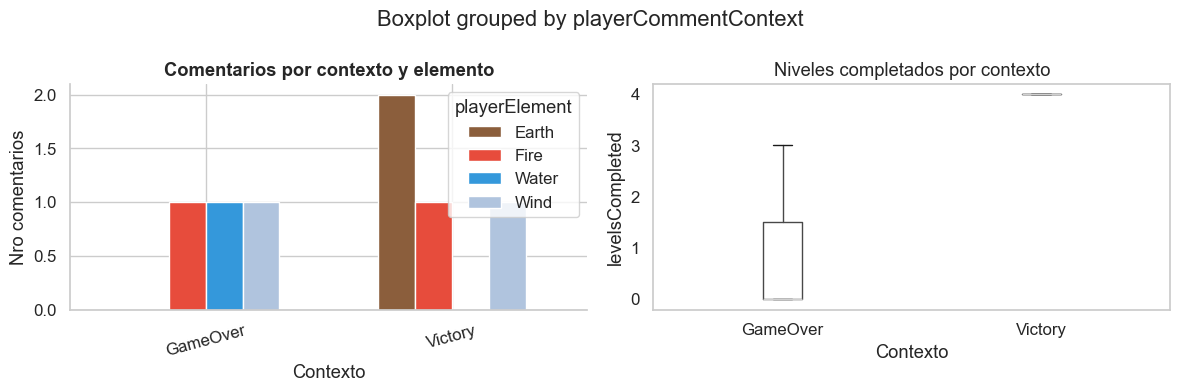

fig6m_comentarios_contexto_elemento.png guardada


In [45]:
df_comm = df_sessions[df_sessions['hasComment']].copy()

if len(df_comm) == 0:
    print('No hay sesiones con comentario')
else:
    print(f'Sesiones con comentario: {len(df_comm)}')
    print()

    # Tabla cruzada: contexto x elemento
    if 'playerCommentContext' in df_comm.columns:
        ct_ctx_elem = pd.crosstab(
            df_comm['playerCommentContext'],
            df_comm['playerElement'],
            margins=True
        )
        print('Tabla: playerCommentContext x playerElement')
        print(ct_ctx_elem)
        print()

    # Tabla cruzada: contexto x isVictory
    ct_ctx_vic = pd.crosstab(
        df_comm['playerCommentContext'] if 'playerCommentContext' in df_comm.columns
        else df_comm['isVictory'].map({True: 'Victory', False: 'GameOver'}),
        df_comm['isVictory'],
        margins=True
    )
    print('Tabla: contexto x isVictory')
    print(ct_ctx_vic)
    print()

    # Niveles completados por contexto
    if 'playerCommentContext' in df_comm.columns:
        lvl_ctx = df_comm.groupby('playerCommentContext')['levelsCompleted'].agg(['mean','count'])
        print('Niveles completados medios por contexto:')
        print(lvl_ctx)
        print()

    # Visualizacion
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Comentarios por contexto y elemento
    ctx_col = 'playerCommentContext' if 'playerCommentContext' in df_comm.columns else 'isVictory'
    ct_plot = pd.crosstab(df_comm[ctx_col], df_comm['playerElement'])
    ct_plot.plot(kind='bar', ax=axes[0],
                 color=[PALETTE_ELEM.get(c, '#999') for c in ct_plot.columns],
                 edgecolor='white', width=0.6)
    axes[0].set_title('Comentarios por contexto y elemento', fontweight='bold')
    axes[0].set_xlabel('Contexto')
    axes[0].set_ylabel('Nro comentarios')
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
    sns.despine(ax=axes[0])

    # Niveles completados por contexto (boxplot o barplot)
    if 'playerCommentContext' in df_comm.columns and df_comm['playerCommentContext'].nunique() > 1:
        df_comm.boxplot(column='levelsCompleted', by='playerCommentContext',
                        ax=axes[1], grid=False)
        axes[1].set_title('Niveles completados por contexto', fontweight='bold')
        axes[1].set_xlabel('Contexto')
        axes[1].set_ylabel('levelsCompleted')
        plt.sca(axes[1])
        plt.title('Niveles completados por contexto')
    else:
        grp = df_comm.groupby('playerElement')['levelsCompleted'].mean()
        colors_elem = [PALETTE_ELEM.get(e, '#999') for e in grp.index]
        axes[1].bar(grp.index, grp.values, color=colors_elem, edgecolor='white')
        axes[1].set_title('Niveles completados medios (sesiones con comentario)', fontweight='bold')
        axes[1].set_xlabel('Elemento')
        axes[1].set_ylabel('levelsCompleted')
        sns.despine(ax=axes[1])

    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'fig6m_comentarios_contexto_elemento.png', bbox_inches='tight')
    plt.show()
    print('fig6m_comentarios_contexto_elemento.png guardada')


**Conclusiones bloque 6m — Comentarios por contexto y elemento:**
- Con n muy pequeño (≤10 comentarios) el análisis es puramente cualitativo.
- Si los jugadores que llegan más lejos (levelsCompleted alto) dejan comentarios más positivos,
  confirma que la experiencia mejora con el progreso.
- Diferencias por elemento en el contexto del comentario pueden señalar frustración específica.

---
## 8. Resumen ejecutivo del EDA

Tabla de hallazgos clave para el análisis de balance.

In [46]:
# Tabla resumen de hallazgos — actualizada con todos los bloques 6b-6i
hallazgos = [
    ('Tasa de victoria',          '20% (6/30)',               'El juego es difícil — solo 1 de cada 5 sesiones acaba en victoria'),
    ('Churn Rate',                '26.9% (7/26 WebGL)',       'Fire y Water ~40% churn — barrera de entrada elevada en Level1'),
    ('Elemento dominante',        'Fire (16/30 sesiones)',    'Earth y Wind con 4 sesiones — datos insuficientes para balance'),
    ('Hechizo más usado',         'Projectile (3302 cast)',   'Pero el menos eficiente y mayor miss rate — desperdicio masivo de maná'),
    ('Hechizo más eficiente',     'Beam (mayor kills/cast)',  'Muy subutilizado — posible infravaloración por jugadores'),
    ('Mayor demanda latente',     'Blast (mayor noMana)',     'Los jugadores quieren usarlo más — reducir coste de maná'),
    ('AOE kills = 0',             'AOE no registra kills',    'Bug de telemetría confirmado — kills reales via killedWith_*Aoe'),
    ('Daño Unknown',              'Fuente sin tag',           'Bug de telemetría — categorizar correctamente en Unity'),
    ('Nivel con más grinding',    'Level1 (attempt máx=14)',  'Mayor tasa de reintento — revisar dificultad inicial'),
    ('Sesiones válidas',          '19/30 para análisis',      'Editor excluidas (3) + churn excluidos (8) del análisis de balance'),
    ('Burn correlaciona victoria','r>0 p<0.05 (status_Burn)', 'Los ganadores aplican ~11x más Burn — daño sostenido es clave'),
    ('Boss kills predictor',      'r≈+0.67 p<0.001',         'Llegar al Boss y matarlo es la métrica más correlacionada con ganar'),
    ('Spike salas 4-5',           'Daño ~136-129 (2x resto)', 'Pico de dificultad en salas 4-5 — revisar diseño o sesgo de superviviente'),
    ('Diversidad hechizos',       '3.8 tipos vic vs 3.1 der', 'Ganadores usan más variedad — p=0.088, casi significativo; añadir al ML'),
    ('RangerCrossbow universal',  'Top dañino todos elementos','Daño sobreescalado globalmente — ajuste no rompe balance entre elementos'),
    ('Hora del día',              '14h = 100% win (n=2)',     'Tendencia tarde > mañana — orientativo, confirmar con más sesiones'),
    ('Primera sala predictor',    'r=-0.35 p=0.067',          'Menos daño en Room_01/Level1 → tendencia a ganar; casi significativo'),
]

df_hallazgos = pd.DataFrame(hallazgos, columns=['Aspecto', 'Valor', 'Observación'])
print(df_hallazgos.to_string(index=False))

exports_dir = Path('..') / 'data' / 'exports'
exports_dir.mkdir(parents=True, exist_ok=True)
df_hallazgos.to_csv(exports_dir / 'eda_hallazgos.csv', index=False)
churn_elem.reset_index().to_csv(exports_dir / 'churn_analysis.csv', index=False)
print(f'\nHallazgos exportados: {len(df_hallazgos)} entradas → data/exports/eda_hallazgos.csv')
print(f'Churn exportado → data/exports/churn_analysis.csv')

                   Aspecto                      Valor                                                               Observación
          Tasa de victoria                 20% (6/30)         El juego es difícil — solo 1 de cada 5 sesiones acaba en victoria
                Churn Rate         26.9% (7/26 WebGL)            Fire y Water ~40% churn — barrera de entrada elevada en Level1
        Elemento dominante      Fire (16/30 sesiones)            Earth y Wind con 4 sesiones — datos insuficientes para balance
         Hechizo más usado     Projectile (3302 cast)    Pero el menos eficiente y mayor miss rate — desperdicio masivo de maná
     Hechizo más eficiente    Beam (mayor kills/cast)                  Muy subutilizado — posible infravaloración por jugadores
     Mayor demanda latente       Blast (mayor noMana)                  Los jugadores quieren usarlo más — reducir coste de maná
             AOE kills = 0      AOE no registra kills           Bug de telemetría confirmado — kills rea

In [47]:
# Listar todas las figuras generadas
figuras = sorted(FIGURES_DIR.glob('fig*.png'))
print(f'Figuras generadas ({len(figuras)}):')
for f in figuras:
    print(f'  {f.name}')

Figuras generadas (63):
  fig0_1_data_quality_issues.png
  fig0_2_impacto_correcciones.png
  fig0_3_churn_rate.png
  fig2_1_distribuciones_sesion.png
  fig2_2_victorias.png
  fig2_3_perfil_jugador.png
  fig2b_churn_rate.png
  fig3_1_funnel_progresion.png
  fig3_2_dificultad_niveles.png
  fig3_3_attempts_grinding.png
  fig4_1_heatmap_muertes_salas.png
  fig4_1_normalidad.png
  fig4_2_boxplots_elemento.png
  fig4_2_firstspell_por_nivel.png
  fig4_3_correlaciones.png
  fig4_3_salas_peligrosas.png
  fig4_4_scatter_victory.png
  fig4_4b_correlaciones_ampliadas.png
  fig4_5_victoria_elemento.png
  fig4_6_mann_kendall.png
  fig4_7_chi2_hechizo_victoria.png
  fig4_8_attempt_vs_deaths.png
  fig4_9_timesecs_vs_deaths.png
  fig5_0_lr_coeficientes.png
  fig5_1_feature_importance.png
  fig5_1_uso_vs_eficiencia_hechizos.png
  fig5_2_nomana_demanda_latente.png
  fig5_2_roc_curves.png
  fig5_3_confusion_matrices.png
  fig5_3_uso_relativo_hechizos.png
  fig5_4_silhouette.png
  fig5_5_cluster_scatter.pn

---
## Conclusiones finales del EDA

**Datos:** 30 sesiones WebGL limpias, 71 niveles, 350+ salas. Muestra de desarrollo — resultados orientativos.

**Principales hallazgos para el balance:**

1. **Hechizos desbalanceados:** Beam (1.12 kills/cast) es ~8x más eficiente que Projectile (0.134) pero se usa 14x menos. El jugador no percibe esta diferencia — posible problema de feedback visual o accesibilidad del hechizo.

2. **Projectile sobredemandado:** 11 intentos fallidos por falta de maná — los jugadores quieren usarlo más. Candidato a reducción de coste de maná.

3. **AOE sin kills registrados:** Necesita investigación — puede ser bug de telemetría o mecánica que no funciona correctamente.

4. **Level1 como barrera de entrada:** Mayor tasa de reintentos (2.9 intentos de media). Si es el nivel tutorial, puede estar demasiado ajustado.

5. **Fuente de daño Unknown:** Bug de telemetría que necesita corrección en Unity antes de análisis estadístico.

**Siguiente paso:** `04_statistics.ipynb` — tests estadísticos para validar estas observaciones.